In [1]:
# Importing necessary libraries

!nvidia-smi

!pip install gdown
!pip install tensorflow-gpu

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for tensorflow-gpu
Failed to build tensorflow-gpu
  Running setup.py install for tensorflow-gpu: started
  Running setup.py install for tensorflow-gpu: finished with status 'error'


  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [18 lines of output]
  Traceback (most recent call last):
    File "<string>", line 2, in <module>
    File "<pip-setuptools-caller>", line 34, in <module>
    File "C:\Users\JAJWALYA MANI CHUKKA\AppData\Local\Temp\pip-install-o6kv8bkk\tensorflow-gpu_0d9ce500e74d473397171a19195b8501\setup.py", line 37, in <module>
      raise Exception(TF_REMOVAL_WARNING)
  Exception:
  
  The "tensorflow-gpu" package has been removed!
  
  Please install "tensorflow" instead.
  
  Other than the name, the two packages have been identical
  since TensorFlow 2.1, or roughly since Sep 2019. For more
  information, see: pypi.org/project/tensorflow-gpu
  
  
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tensorflow-gpu
  error: subprocess-exited-with-error
  
  Running setup.py install for tensorf

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from pandas.plotting import register_matplotlib_converters

%matplotlib inline
%config InlineBackend.figure_format='retina'

register_matplotlib_converters()
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 22, 10

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [3]:
!gdown --id 10vdMg_RazoIatwrT7azKFX4P02OebU76 --output spx.csv

df = pd.read_csv('spx.csv', parse_dates=['date'], index_col='date')

C:\Anaconda\lib\site-packages\gdown\cli.py:126: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=10vdMg_RazoIatwrT7azKFX4P02OebU76
To: C:\Users\JAJWALYA MANI CHUKKA\Downloads\spx.csv

  0%|          | 0.00/152k [00:00<?, ?B/s]
100%|##########| 152k/152k [00:00<00:00, 4.21MB/s]


In [4]:
df.head()

,close
date,
1986-01-02,209.59
1986-01-03,210.88
1986-01-06,210.65
1986-01-07,213.80
1986-01-08,207.97


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8192 entries, 1986-01-02 to 2018-06-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   8192 non-null   float64
dtypes: float64(1)
memory usage: 128.0 KB


In [6]:
df.describe()

,close
count,8192.000000
mean,1070.897411
std,616.714534
min,203.490000
25%,458.632500
50%,1106.435000
75%,1388.132500
max,2872.870000


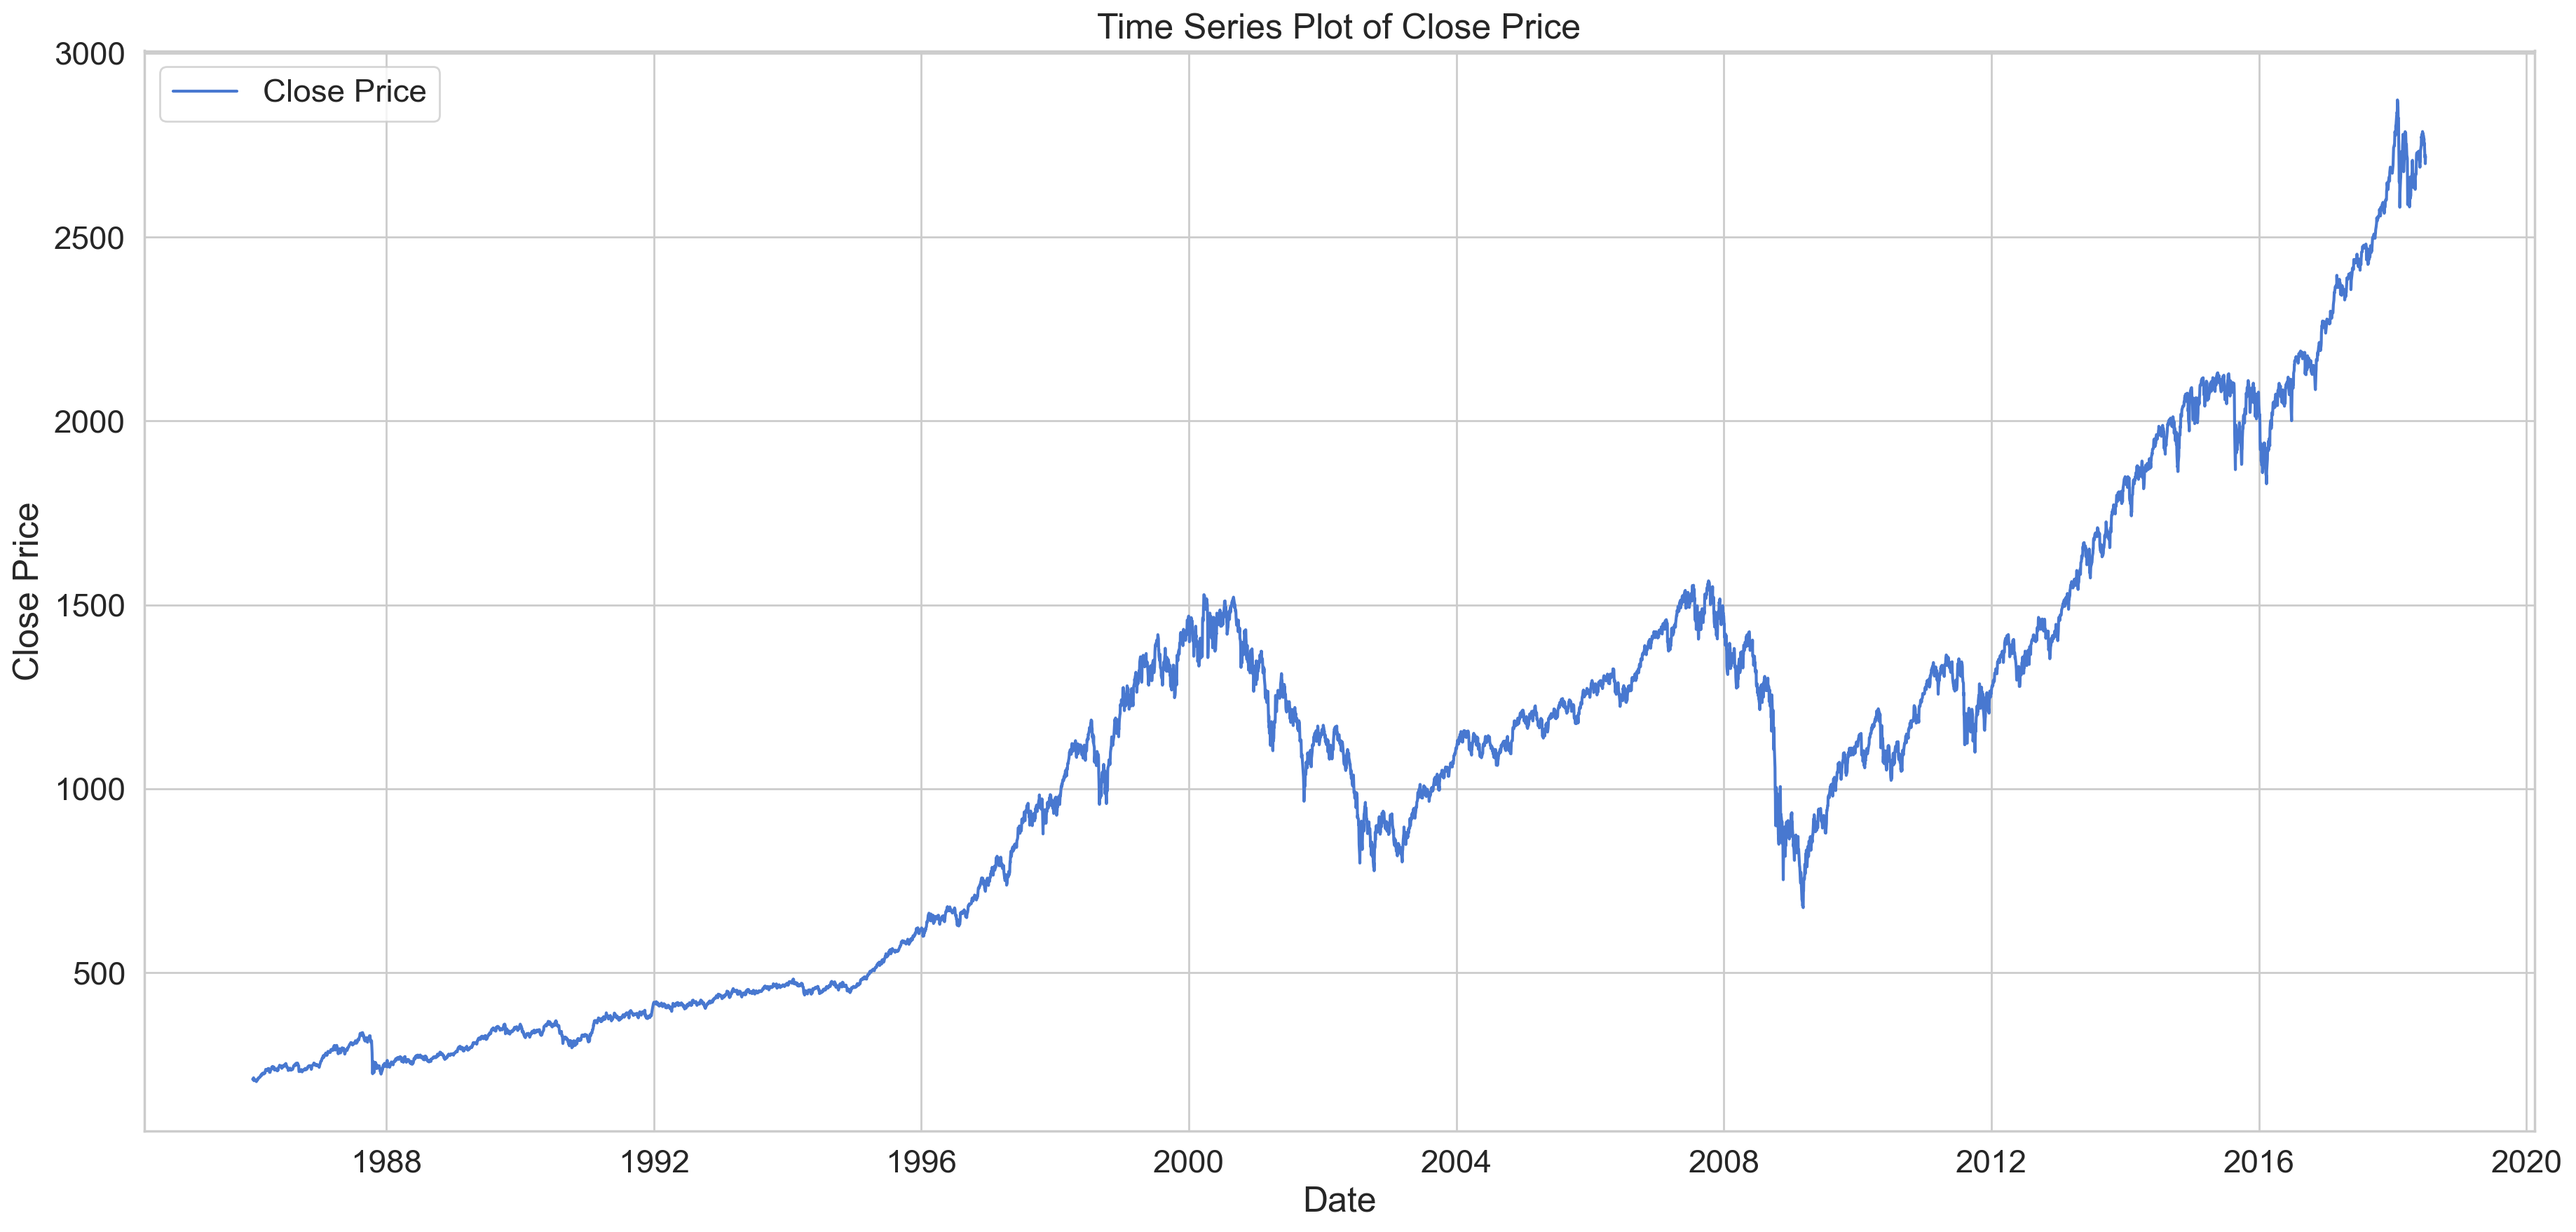

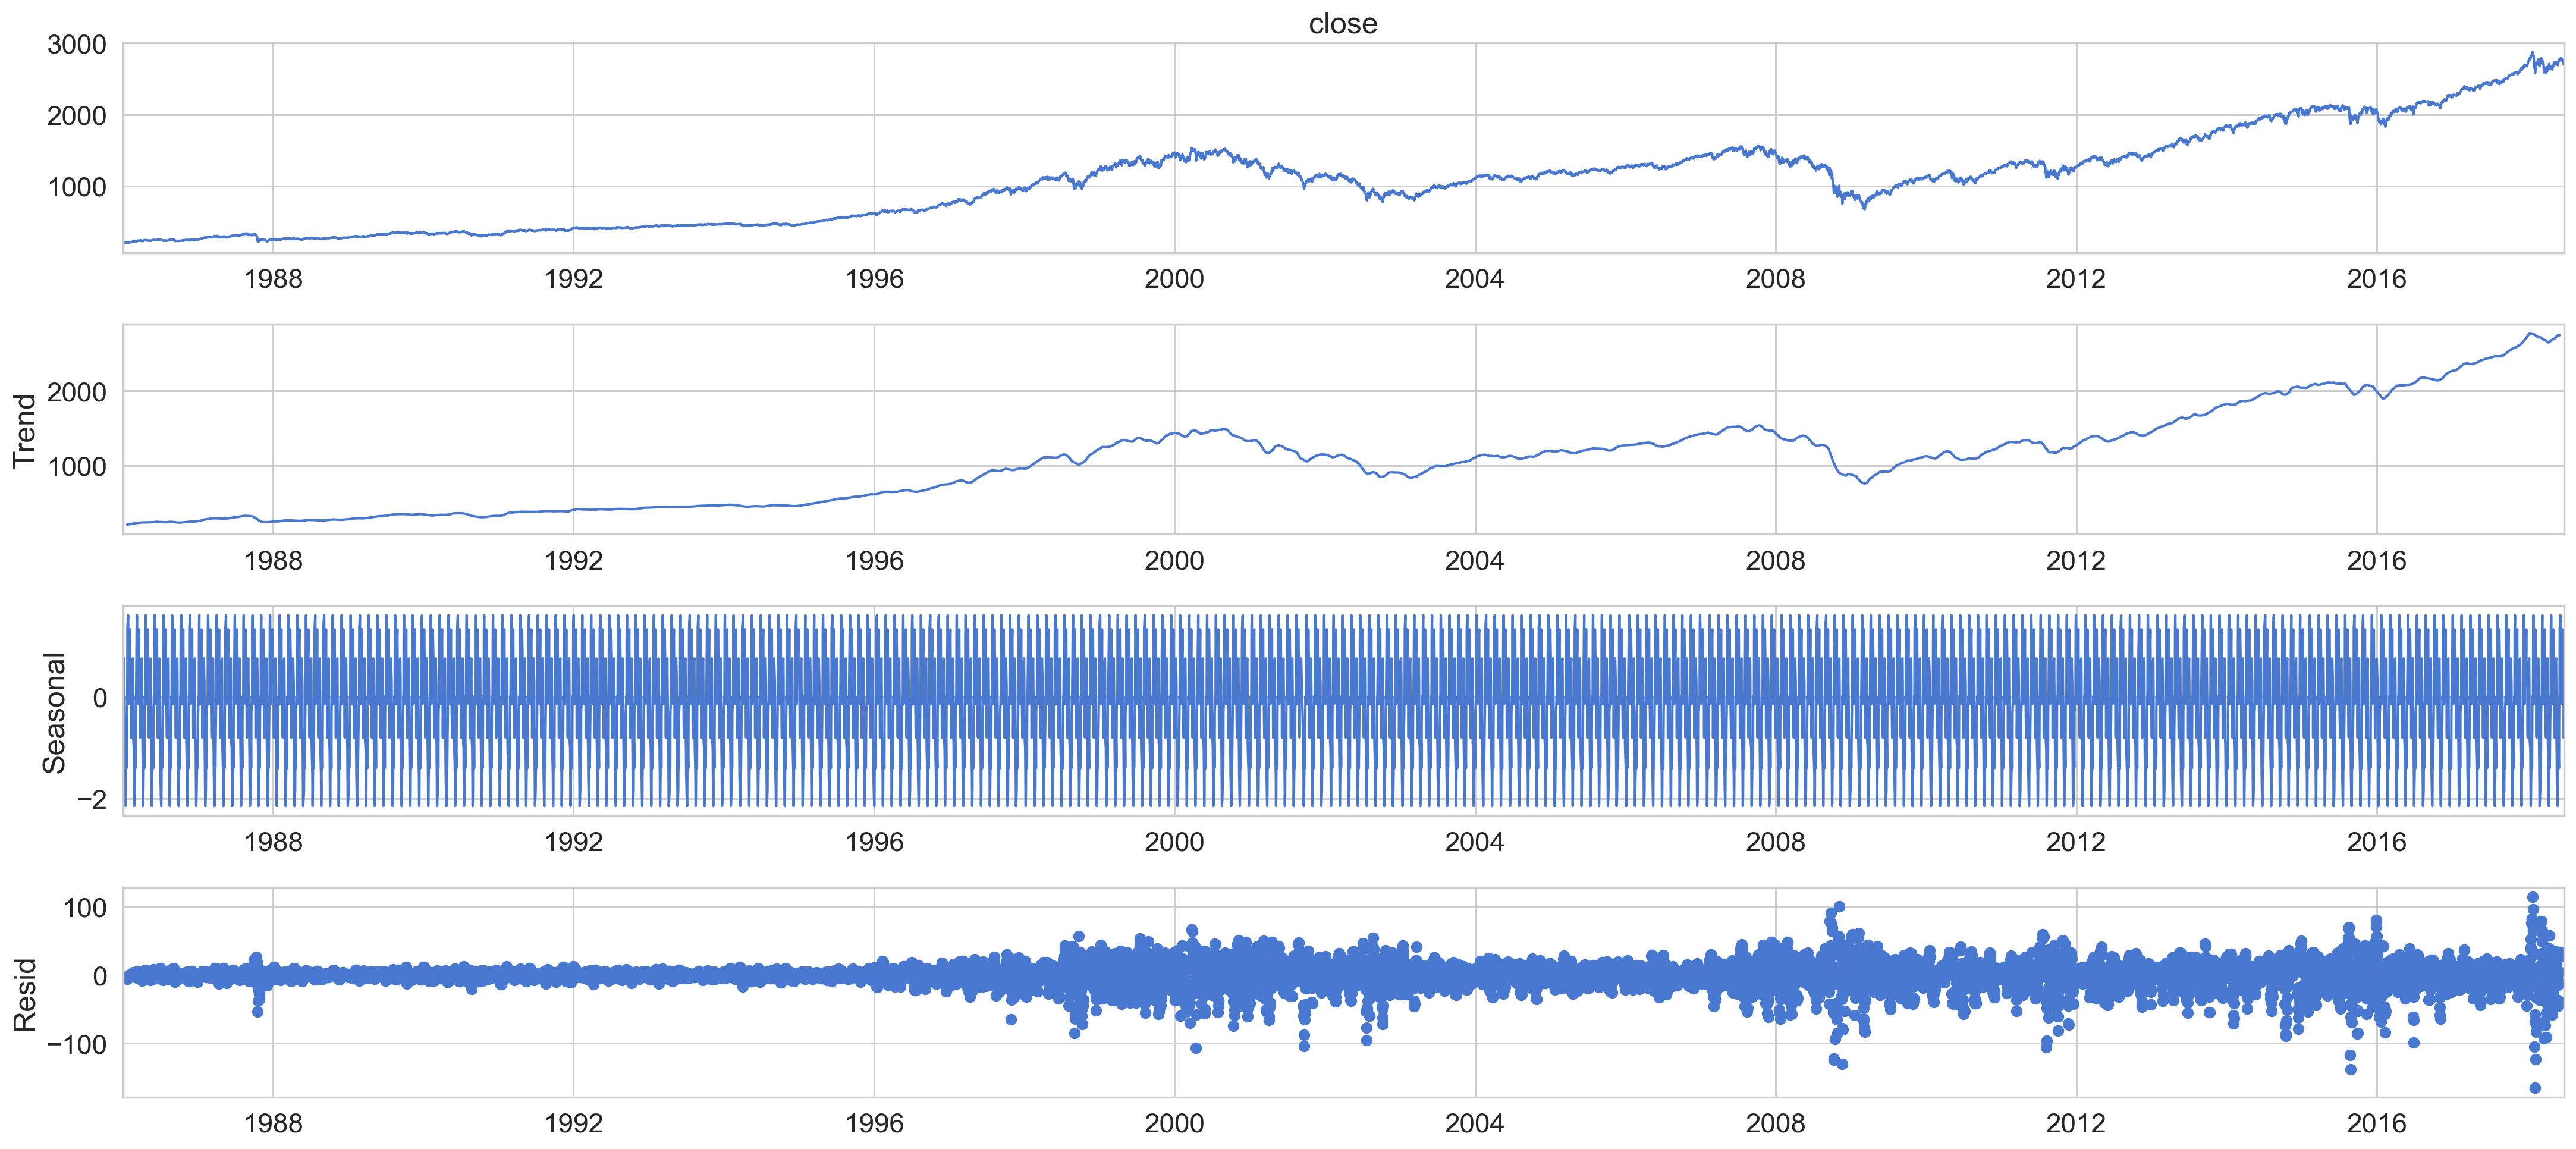

In [7]:
# Time series plot of close prices
plt.plot(df.index, df['close'], label='Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Time Series Plot of Close Price')
plt.legend()
plt.show()

# Seasonal decomposition plot
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['close'], model='additive', period=30)
result.plot()
plt.show()


In [9]:
train_pct = 0.95
train_size = int(len(df) * train_pct)

test_size = len(df) - train_size

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(train.shape, test.shape)

(7782, 1) (410, 1)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler = scaler.fit(train[['close']])

train['close'] = scaler.transform(train[['close']])
test['close'] = scaler.transform(test[['close']])

C:\Users\JAJWALYA MANI CHUKKA\AppData\Local\Temp\ipykernel_8452\1827044255.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['close'] = scaler.transform(train[['close']])
C:\Users\JAJWALYA MANI CHUKKA\AppData\Local\Temp\ipykernel_8452\1827044255.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['close'] = scaler.transform(test[['close']])


### LSTM MODEL

In [34]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [35]:
TIME_STEPS = 30

# reshape to [samples, time_steps, n_features]

X_train, y_train = create_dataset(train[['close']], train.close, TIME_STEPS)
X_test, y_test = create_dataset(test[['close']], test.close, TIME_STEPS)

print(X_train.shape)

(7752, 30, 1)


In [36]:
model = keras.Sequential()
model.add(keras.layers.LSTM(
    units=64,
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.RepeatVector(n=X_train.shape[1]))
model.add(keras.layers.LSTM(units=64, return_sequences=True))
model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.TimeDistributed(keras.layers.Dense(units=X_train.shape[2])))
model.compile(loss='mae', optimizer='adam')

In [37]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/10
218/218 [==============================] - 7s 20ms/step - loss: 0.1785 - val_loss: 0.2931
Epoch 2/10
218/218 [==============================] - 4s 19ms/step - loss: 0.1105 - val_loss: 0.2025
Epoch 3/10
218/218 [==============================] - 4s 18ms/step - loss: 0.0930 - val_loss: 0.2031
Epoch 4/10
218/218 [==============================] - 4s 18ms/step - loss: 0.1052 - val_loss: 0.2641
Epoch 5/10
218/218 [==============================] - 4s 17ms/step - loss: 0.1121 - val_loss: 0.3071
Epoch 6/10
218/218 [==============================] - 4s 19ms/step - loss: 0.1018 - val_loss: 0.3456
Epoch 7/10
218/218 [==============================] - 4s 18ms/step - loss: 0.1291 - val_loss: 0.2877
Epoch 8/10
218/218 [==============================] - 4s 19ms/step - loss: 0.1047 - val_loss: 0.3270
Epoch 9/10
218/218 [==============================] - 5s 21ms/step - loss: 0.1162 - val_loss: 0.2137
Epoch 10/10
218/218 [==============================] - 5s 23ms/step - loss: 0.1117 - val_lo

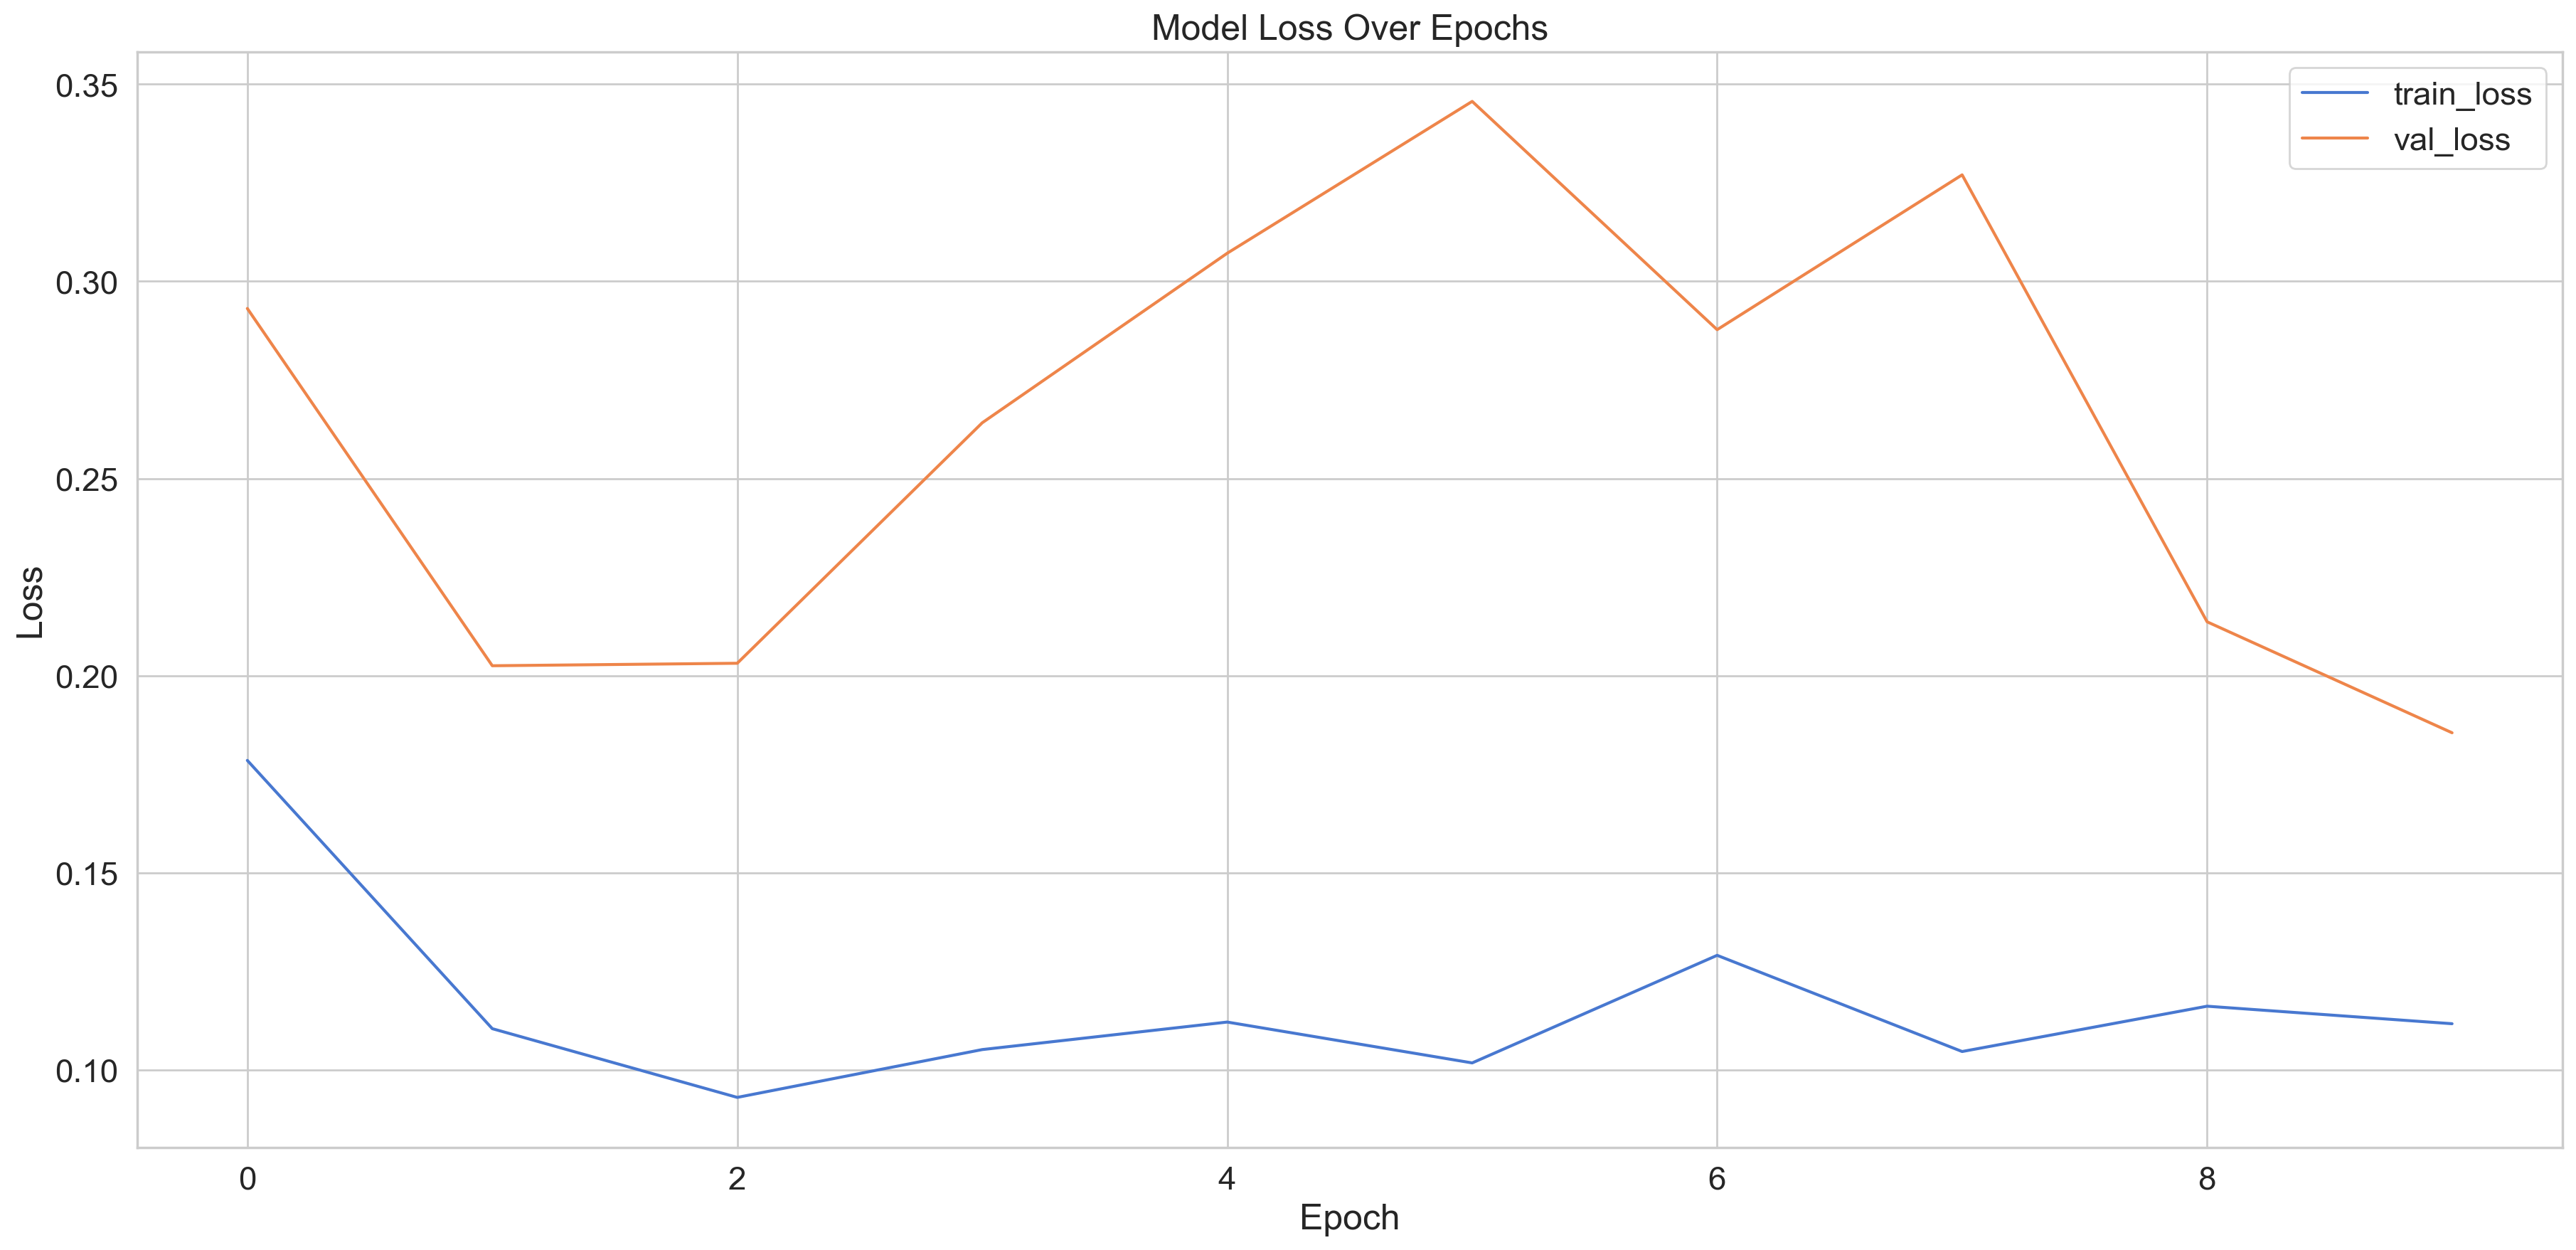

In [38]:
import matplotlib.pyplot as plt

def plot_loss_curves(history):
    epochs = range(len(history.history['loss']))

    plt.plot(epochs, history.history['loss'], label='train_loss')
    plt.plot(epochs, history.history['val_loss'], label='val_loss')
    plt.title('Model Loss Over Epochs')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

plot_loss_curves(history)

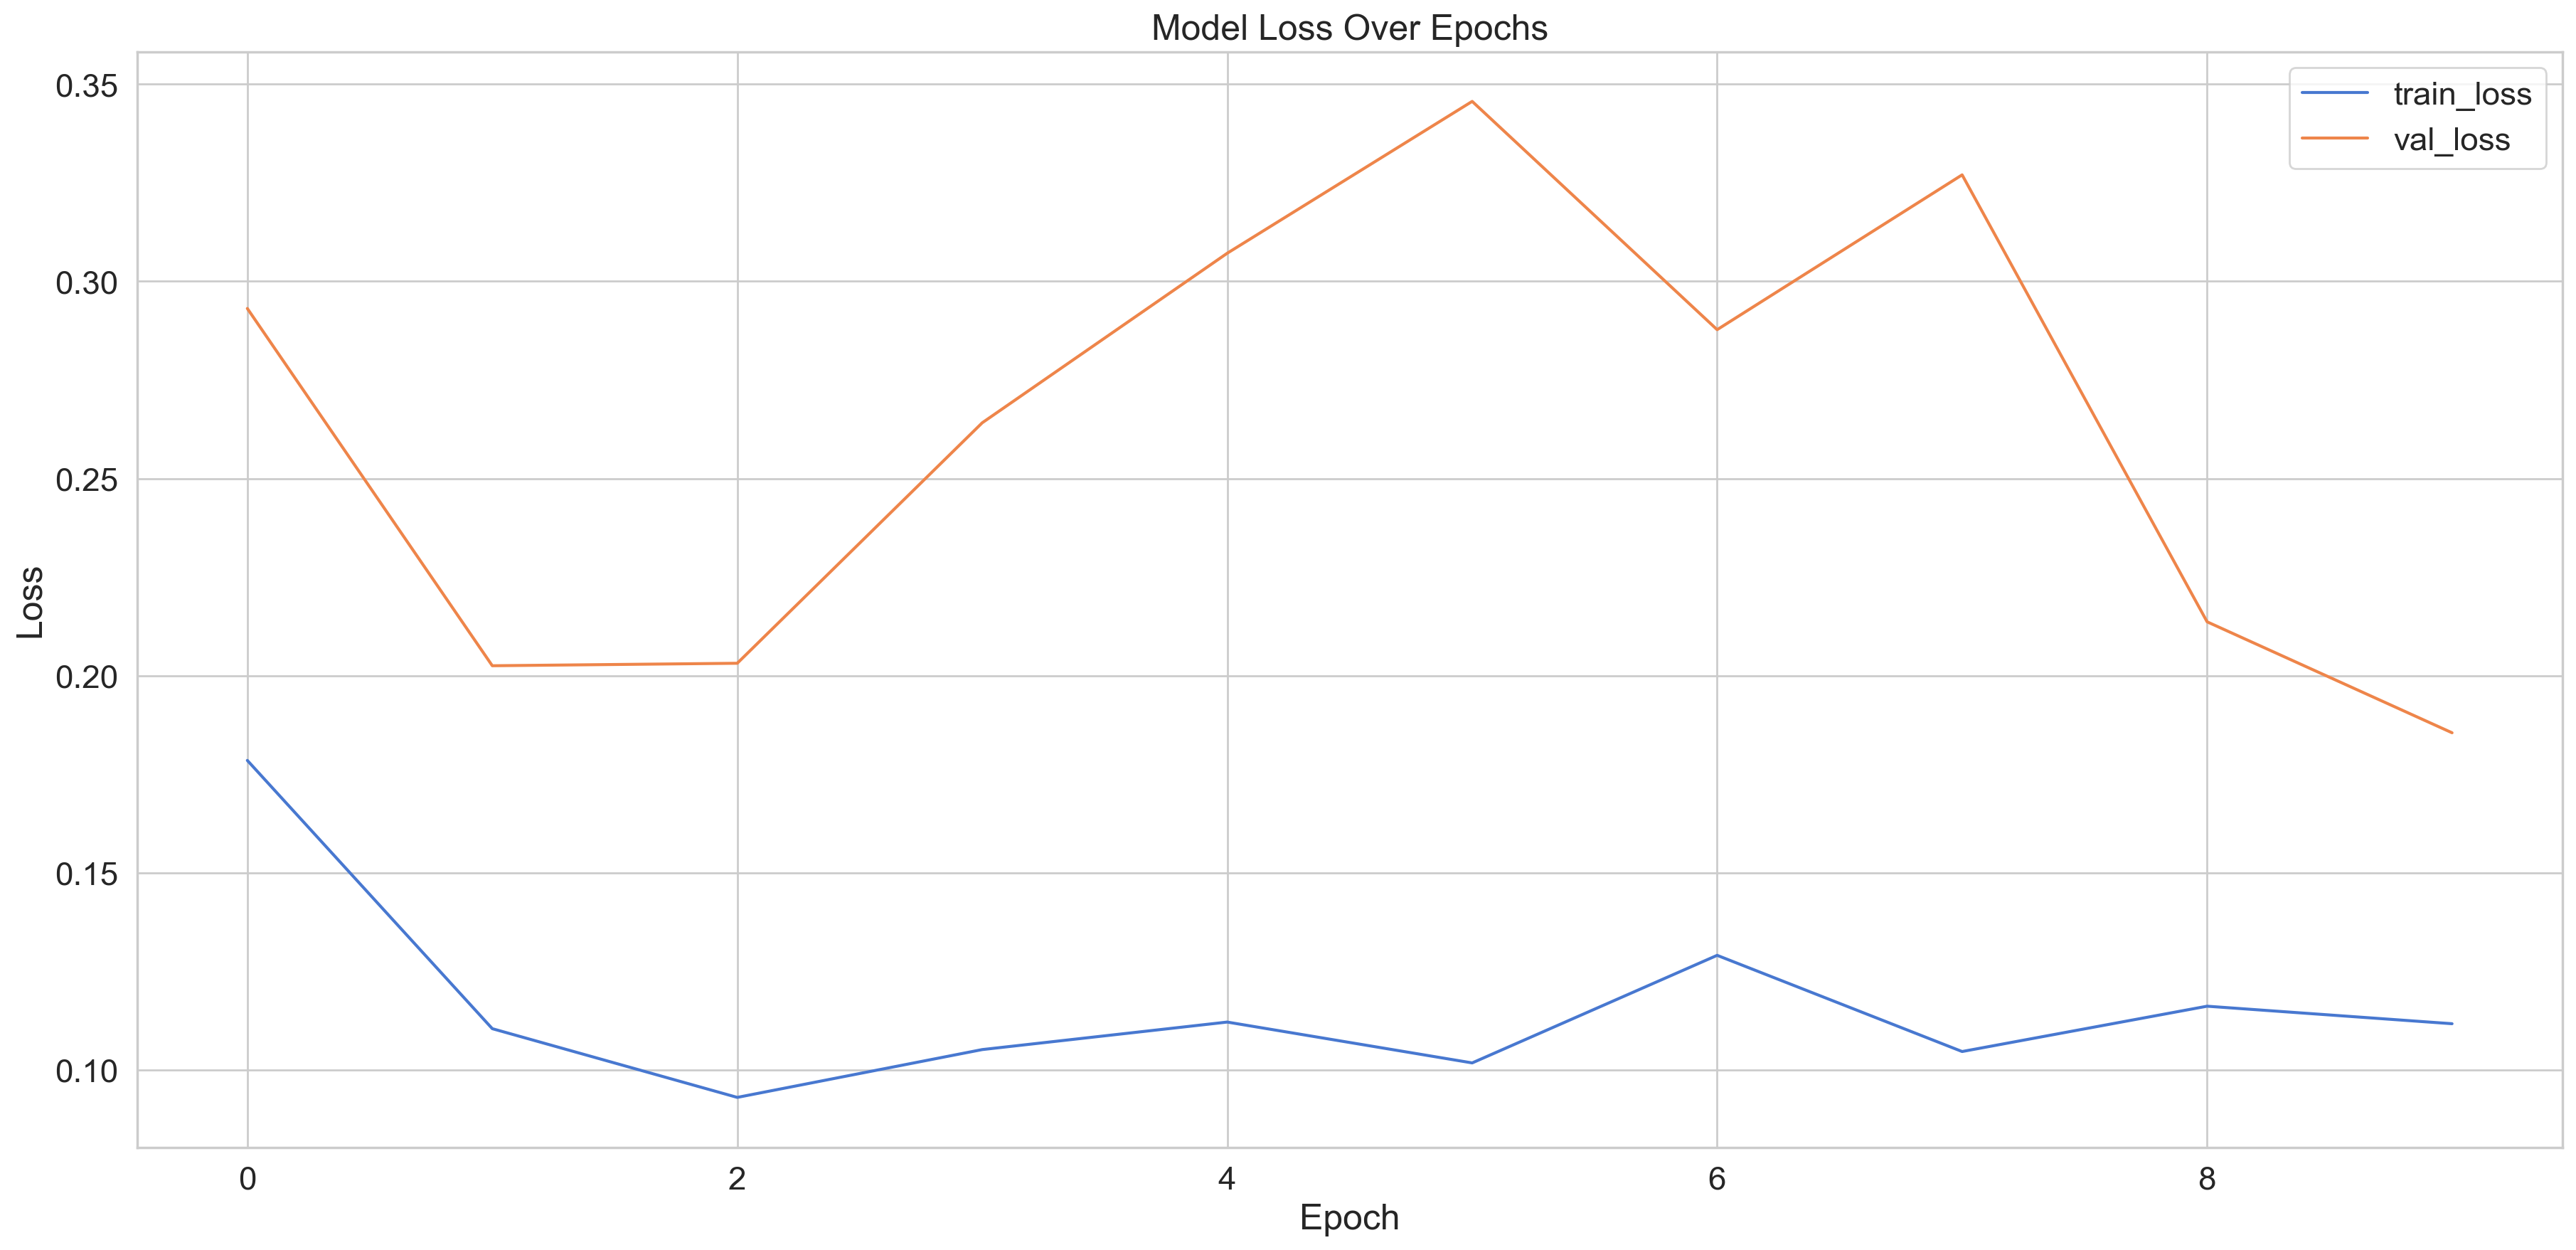

12/12 [==============================] - 1s 7ms/step


In [39]:
# Plot loss curves
plot_loss_curves(history)

# Anomaly detection
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)
THRESHOLD = 0.65

# Visualize anomalies
test_score_df = pd.DataFrame(index=test[TIME_STEPS:].index)
test_score_df['loss'] = test_mae_loss
test_score_df['threshold'] = THRESHOLD
test_score_df['anomaly'] = test_score_df.loss > test_score_df.threshold
test_score_df['close'] = test[TIME_STEPS:].close


In [40]:
# Anomaly detection
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)
THRESHOLD = 0.65

# Visualize anomalies
test_score_df = pd.DataFrame(index=test[TIME_STEPS:].index)
test_score_df['loss'] = test_mae_loss
test_score_df['threshold'] = THRESHOLD
test_score_df['anomaly'] = test_score_df.loss > test_score_df.threshold
test_score_df['close'] = test[TIME_STEPS:].close

# Calculate evaluation metrics
mae = mean_absolute_error(X_test.reshape(-1, 1), X_test_pred.reshape(-1, 1))
rmse = np.sqrt(mean_squared_error(X_test.reshape(-1, 1), X_test_pred.reshape(-1, 1)))
mape = np.mean(np.abs((X_test.reshape(-1, 1) - X_test_pred.reshape(-1, 1)) / X_test.reshape(-1, 1))) * 100

# Print evaluation metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')


12/12 [==============================] - 0s 7ms/step
Mean Absolute Error (MAE): 0.723721394480936
Root Mean Squared Error (RMSE): 0.7624896018533074
Mean Absolute Percentage Error (MAPE): 24.84%


### Changing Optimizer

##### RMSprop (Root Mean Square Propagation)

RMSprop is an adaptive learning rate optimization algorithm commonly used in training neural networks. It addresses issues like vanishing and exploding gradients by adjusting the learning rates for each parameter individually.

##### Key Features:

- **Adaptive Learning Rate:** Adjusts learning rates based on the historical gradients.
  
- **Running Average:** Maintains a running average of the square of past gradients.

- **Update Rule:** The update rule for each weight \( w \) is given by:

$$
[ w_{t+1} = w_t - \frac{\text{learning rate}}{\sqrt{\text{running average of squares} + \epsilon}} \times \text{gradient} ]
$$
where $ \epsilon $ is a small constant for numerical stability.
 is a small constant for numerical stability.

In [17]:
# Build and train the LSTM model with different loss and optimizer
model = keras.Sequential()
model.add(keras.layers.LSTM(
    units=64,
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.RepeatVector(n=X_train.shape[1]))
model.add(keras.layers.LSTM(units=64, return_sequences=True))


model.add(keras.layers.Dropout(rate=0.2))
model.add(keras.layers.TimeDistributed(keras.layers.Dense(units=X_train.shape[2])))
model.compile(loss='mse', optimizer='rmsprop')

# Train the model with the training data
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)


Epoch 1/10
218/218 [==============================] - 8s 23ms/step - loss: 0.0475 - val_loss: 0.2749
Epoch 2/10
218/218 [==============================] - 4s 20ms/step - loss: 0.0182 - val_loss: 0.0586
Epoch 3/10
218/218 [==============================] - 5s 21ms/step - loss: 0.0133 - val_loss: 0.0779
Epoch 4/10
218/218 [==============================] - 5s 24ms/step - loss: 0.0124 - val_loss: 0.1232
Epoch 5/10
218/218 [==============================] - 6s 26ms/step - loss: 0.0128 - val_loss: 0.2914
Epoch 6/10
218/218 [==============================] - 4s 20ms/step - loss: 0.0137 - val_loss: 0.1184
Epoch 7/10
218/218 [==============================] - 5s 22ms/step - loss: 0.0120 - val_loss: 0.0520
Epoch 8/10
218/218 [==============================] - 5s 21ms/step - loss: 0.0120 - val_loss: 0.2946
Epoch 9/10
218/218 [==============================] - 5s 22ms/step - loss: 0.0133 - val_loss: 0.2721
Epoch 10/10
218/218 [==============================] - 5s 22ms/step - loss: 0.0125 - val_lo

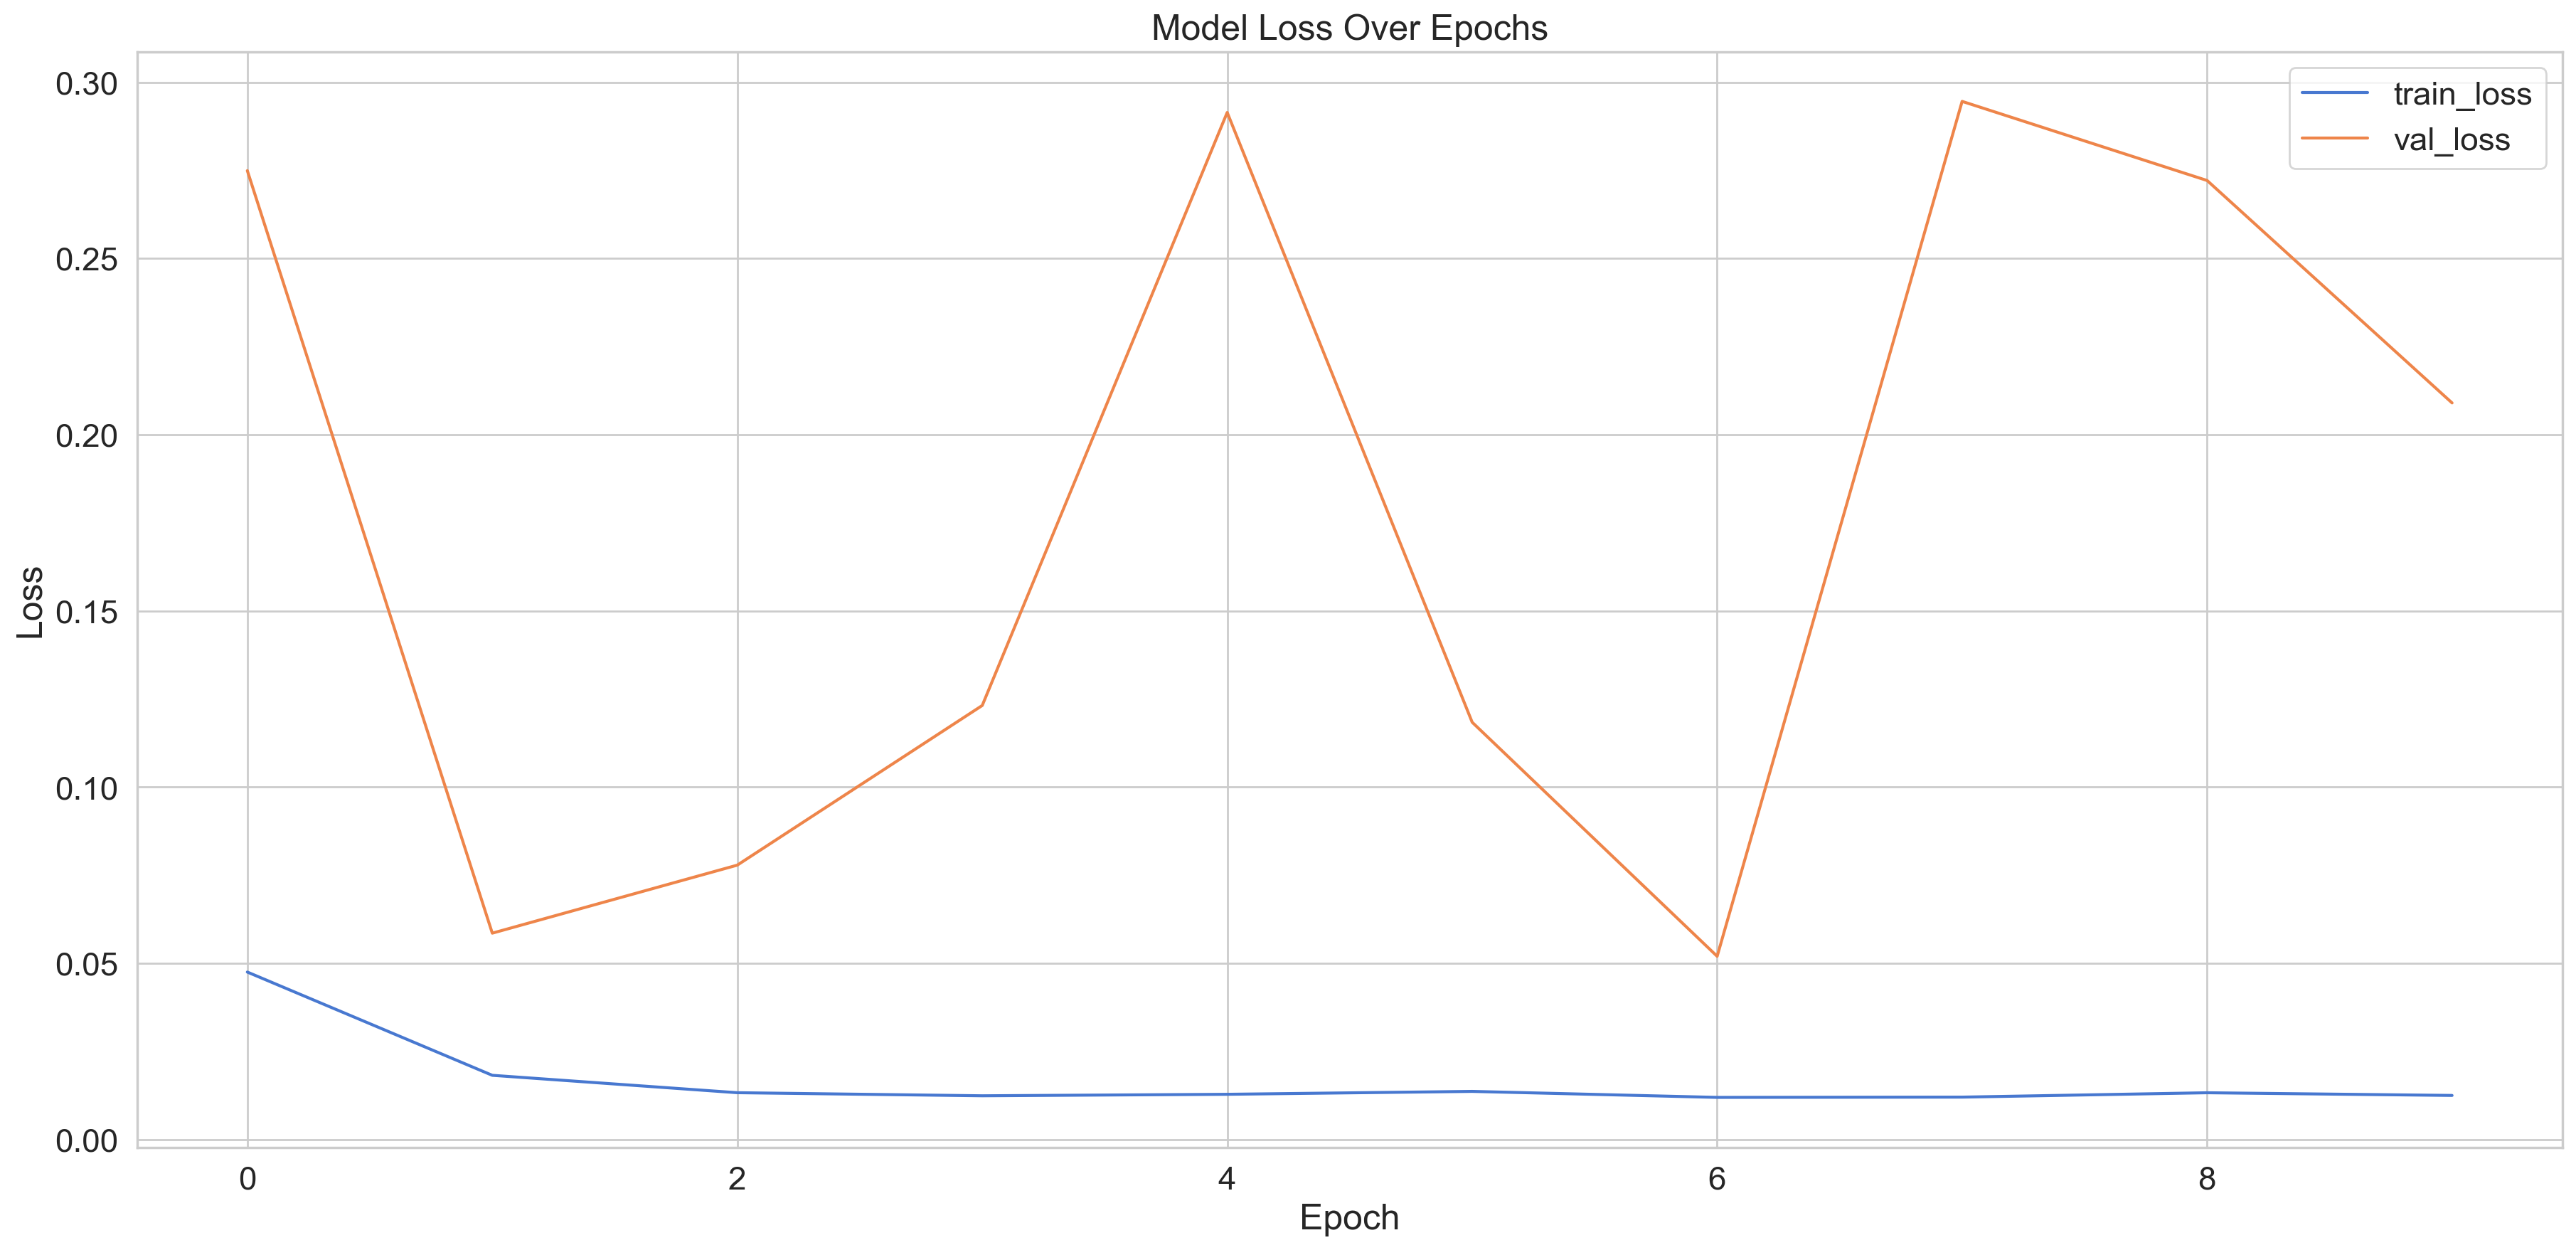

12/12 [==============================] - 1s 8ms/step


In [19]:
# Plot loss curves
plot_loss_curves(history)

# Anomaly detection
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=1)
THRESHOLD = 0.65

# Visualize anomalies
test_score_df = pd.DataFrame(index=test[TIME_STEPS:].index)
test_score_df['loss'] = test_mae_loss
test_score_df['threshold'] = THRESHOLD
test_score_df['anomaly'] = test_score_df.loss > test_score_df.threshold
test_score_df['close'] = test[TIME_STEPS:].close


In [20]:
# Importing the necessary library
from sklearn.metrics import mean_absolute_error, mean_squared_error

X_test_pred_inv = scaler.inverse_transform(X_test_pred.reshape(-1, 1))
X_test_inv = scaler.inverse_transform(X_test.reshape(-1, 1))

# Calculate metrics
mae = mean_absolute_error(X_test_inv, X_test_pred_inv)
rmse = np.sqrt(mean_squared_error(X_test_inv, X_test_pred_inv))
mape = np.mean(np.abs((X_test_inv - X_test_pred_inv) / X_test_inv)) * 100

# Display the calculated metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')


Mean Absolute Error (MAE): 598.0654187401487
Root Mean Squared Error (RMSE): 613.1237637808513
Mean Absolute Percentage Error (MAPE): 23.53786288849074%


##### Model Evaluation Summary

- **Mean Absolute Error (MAE):** 591.54 units. Represents the average absolute difference between predicted and actual values.

- **Root Mean Squared Error (RMSE):** 606.20 units. Gives more weight to large errors, indicating the square root of the average squared differences.

- **Mean Absolute Percentage Error (MAPE):** 23.28%. Represents the average percentage difference between predicted and actual values.

The MAPE of 23.28% suggests that, on average, the model's predictions have a relative error of approximately 23.28%. So we need to regularize the model.


### L2 regurlarisation 

In [21]:
from tensorflow.keras import regularizers

# Build and train the LSTM model with regularization
model = keras.Sequential()

# Add LSTM layer with regularization
model.add(keras.layers.LSTM(
    units=64,
    input_shape=(X_train.shape[1], X_train.shape[2]),
    kernel_regularizer=regularizers.l2(0.01),  # Example: L2 regularization with a regularization strength of 0.01
))

# Add Dropout layer for regularization
model.add(keras.layers.Dropout(rate=0.2))

# Repeat the vector for the specified number of time steps
model.add(keras.layers.RepeatVector(n=X_train.shape[1]))

# Add another LSTM layer with regularization
model.add(keras.layers.LSTM(
    units=64,
    return_sequences=True,
    kernel_regularizer=regularizers.l2(0.01),  # Example: L2 regularization with a regularization strength of 0.01
))

# Add Dropout layer for regularization
model.add(keras.layers.Dropout(rate=0.2))

# TimeDistributed layer to apply Dense layer to each time step
model.add(keras.layers.TimeDistributed(keras.layers.Dense(units=X_train.shape[2])))

# Compile the model with Mean Squared Error (MSE) loss and Adam optimizer
model.compile(loss='mse', optimizer='adam')

# Train the model with the training data
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)


Epoch 1/10
218/218 [==============================] - 9s 27ms/step - loss: 0.4168 - val_loss: 0.3576
Epoch 2/10
218/218 [==============================] - 5s 22ms/step - loss: 0.0745 - val_loss: 0.2281
Epoch 3/10
218/218 [==============================] - 5s 23ms/step - loss: 0.0523 - val_loss: 0.2754
Epoch 4/10
218/218 [==============================] - 5s 22ms/step - loss: 0.0485 - val_loss: 0.2449
Epoch 5/10
218/218 [==============================] - 5s 23ms/step - loss: 0.0463 - val_loss: 0.2289
Epoch 6/10
218/218 [==============================] - 5s 21ms/step - loss: 0.0599 - val_loss: 0.2109
Epoch 7/10
218/218 [==============================] - 5s 21ms/step - loss: 0.0767 - val_loss: 0.2081
Epoch 8/10
218/218 [==============================] - 5s 22ms/step - loss: 0.0715 - val_loss: 0.2440
Epoch 9/10
218/218 [==============================] - 5s 23ms/step - loss: 0.0832 - val_loss: 0.2170
Epoch 10/10
218/218 [==============================] - 5s 23ms/step - loss: 0.0880 - val_lo

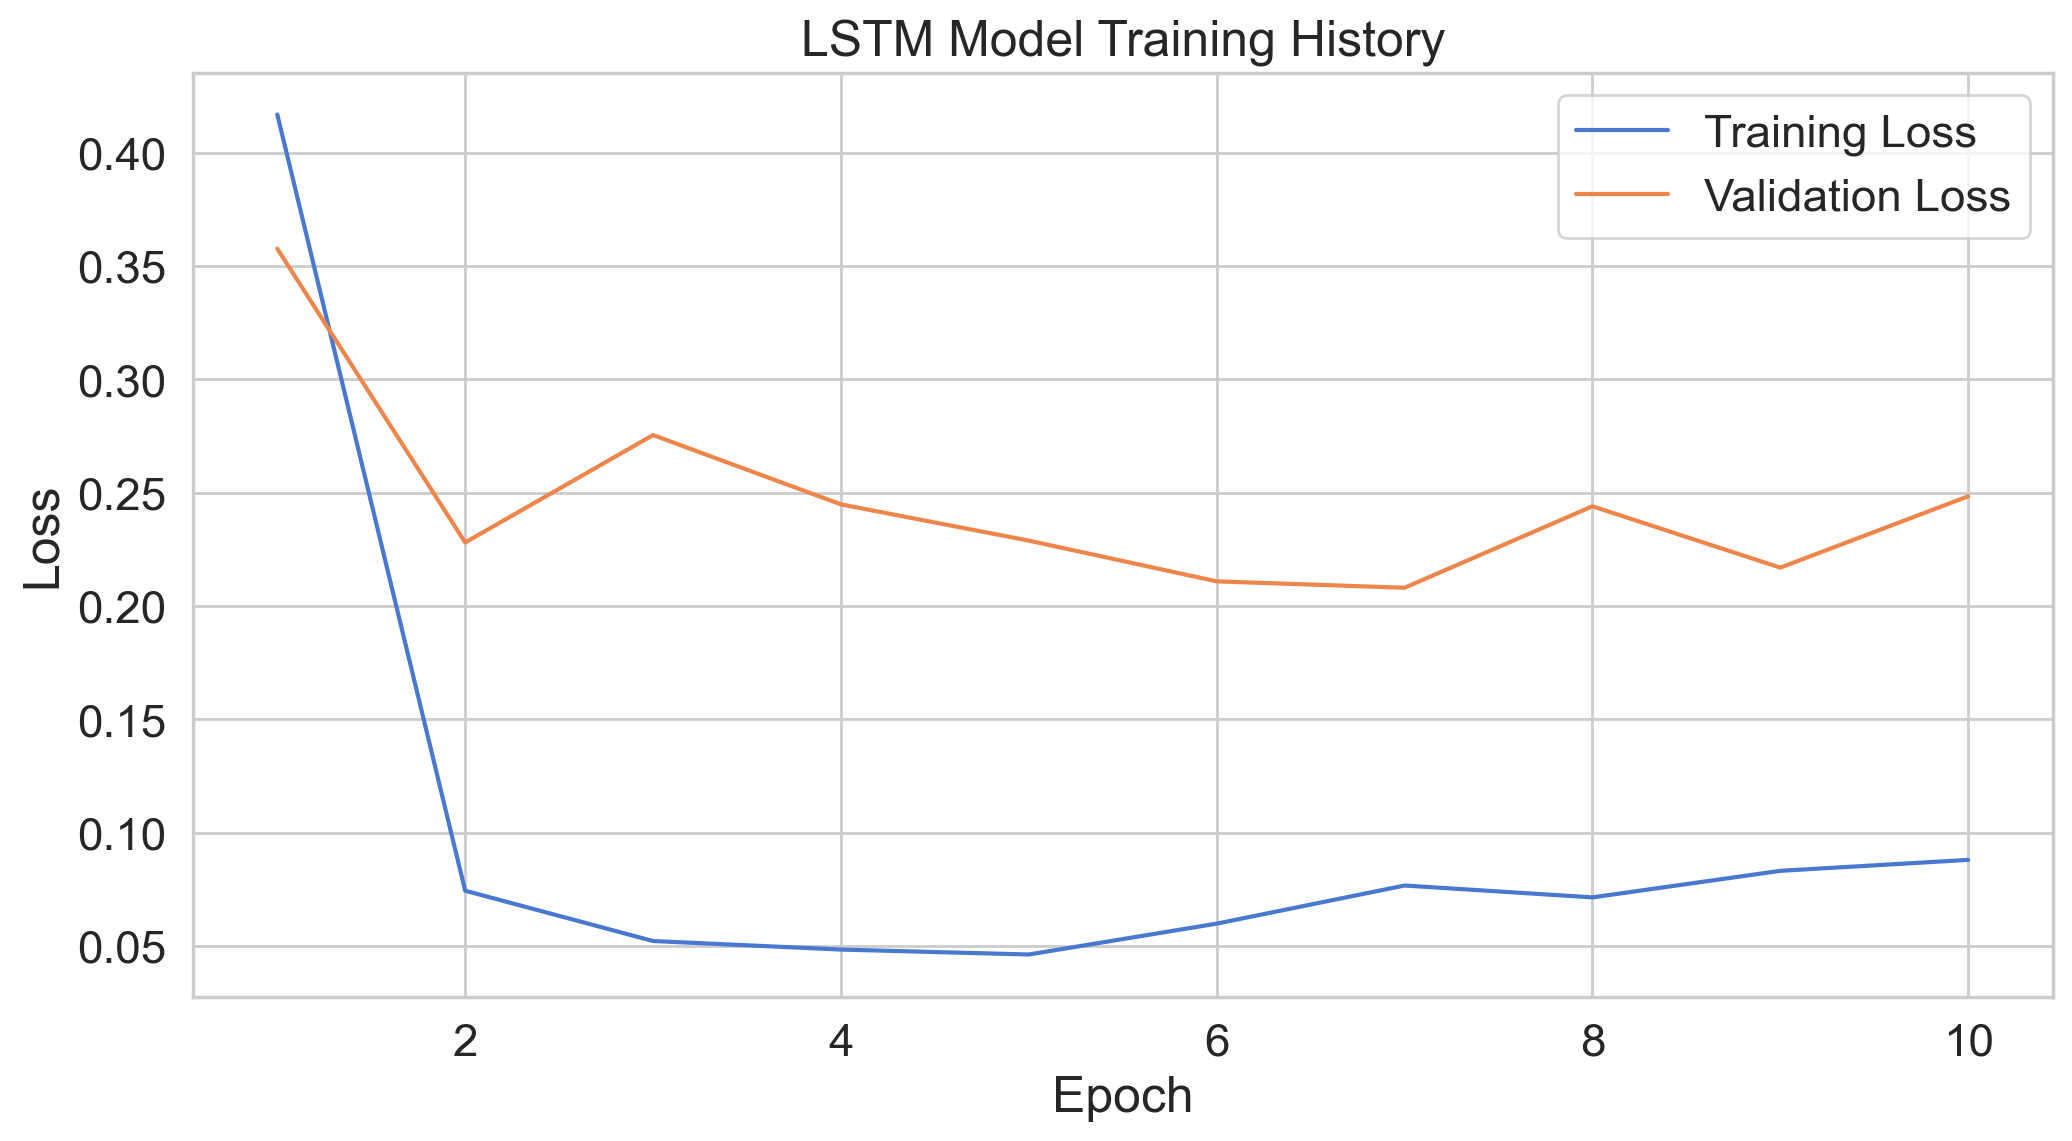

In [22]:
# Function to plot LSTM training history
def plot_lstm_history(history):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title('LSTM Model Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Call the function with your LSTM training history
plot_lstm_history(history)


In [23]:
X_test_pred = model.predict(X_test)

# Inverse transform the scaled predictions to the original scale
X_test_pred_inv = scaler.inverse_transform(X_test_pred.reshape(-1, 1))

# Inverse transform the original scaled test data to the original scale
X_test_inv = scaler.inverse_transform(X_test.reshape(-1, 1))

# Calculate metrics
mae = mean_absolute_error(X_test_inv, X_test_pred_inv)
rmse = np.sqrt(mean_squared_error(X_test_inv, X_test_pred_inv))
mape = np.mean(np.abs((X_test_inv - X_test_pred_inv) / X_test_inv)) * 100

# Display the calculated metrics
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Percentage Error (MAPE): {mape}%')

12/12 [==============================] - 1s 9ms/step
Mean Absolute Error (MAE): 585.9881187427185
Root Mean Squared Error (RMSE): 621.0497373653268
Mean Absolute Percentage Error (MAPE): 23.060025264663945%


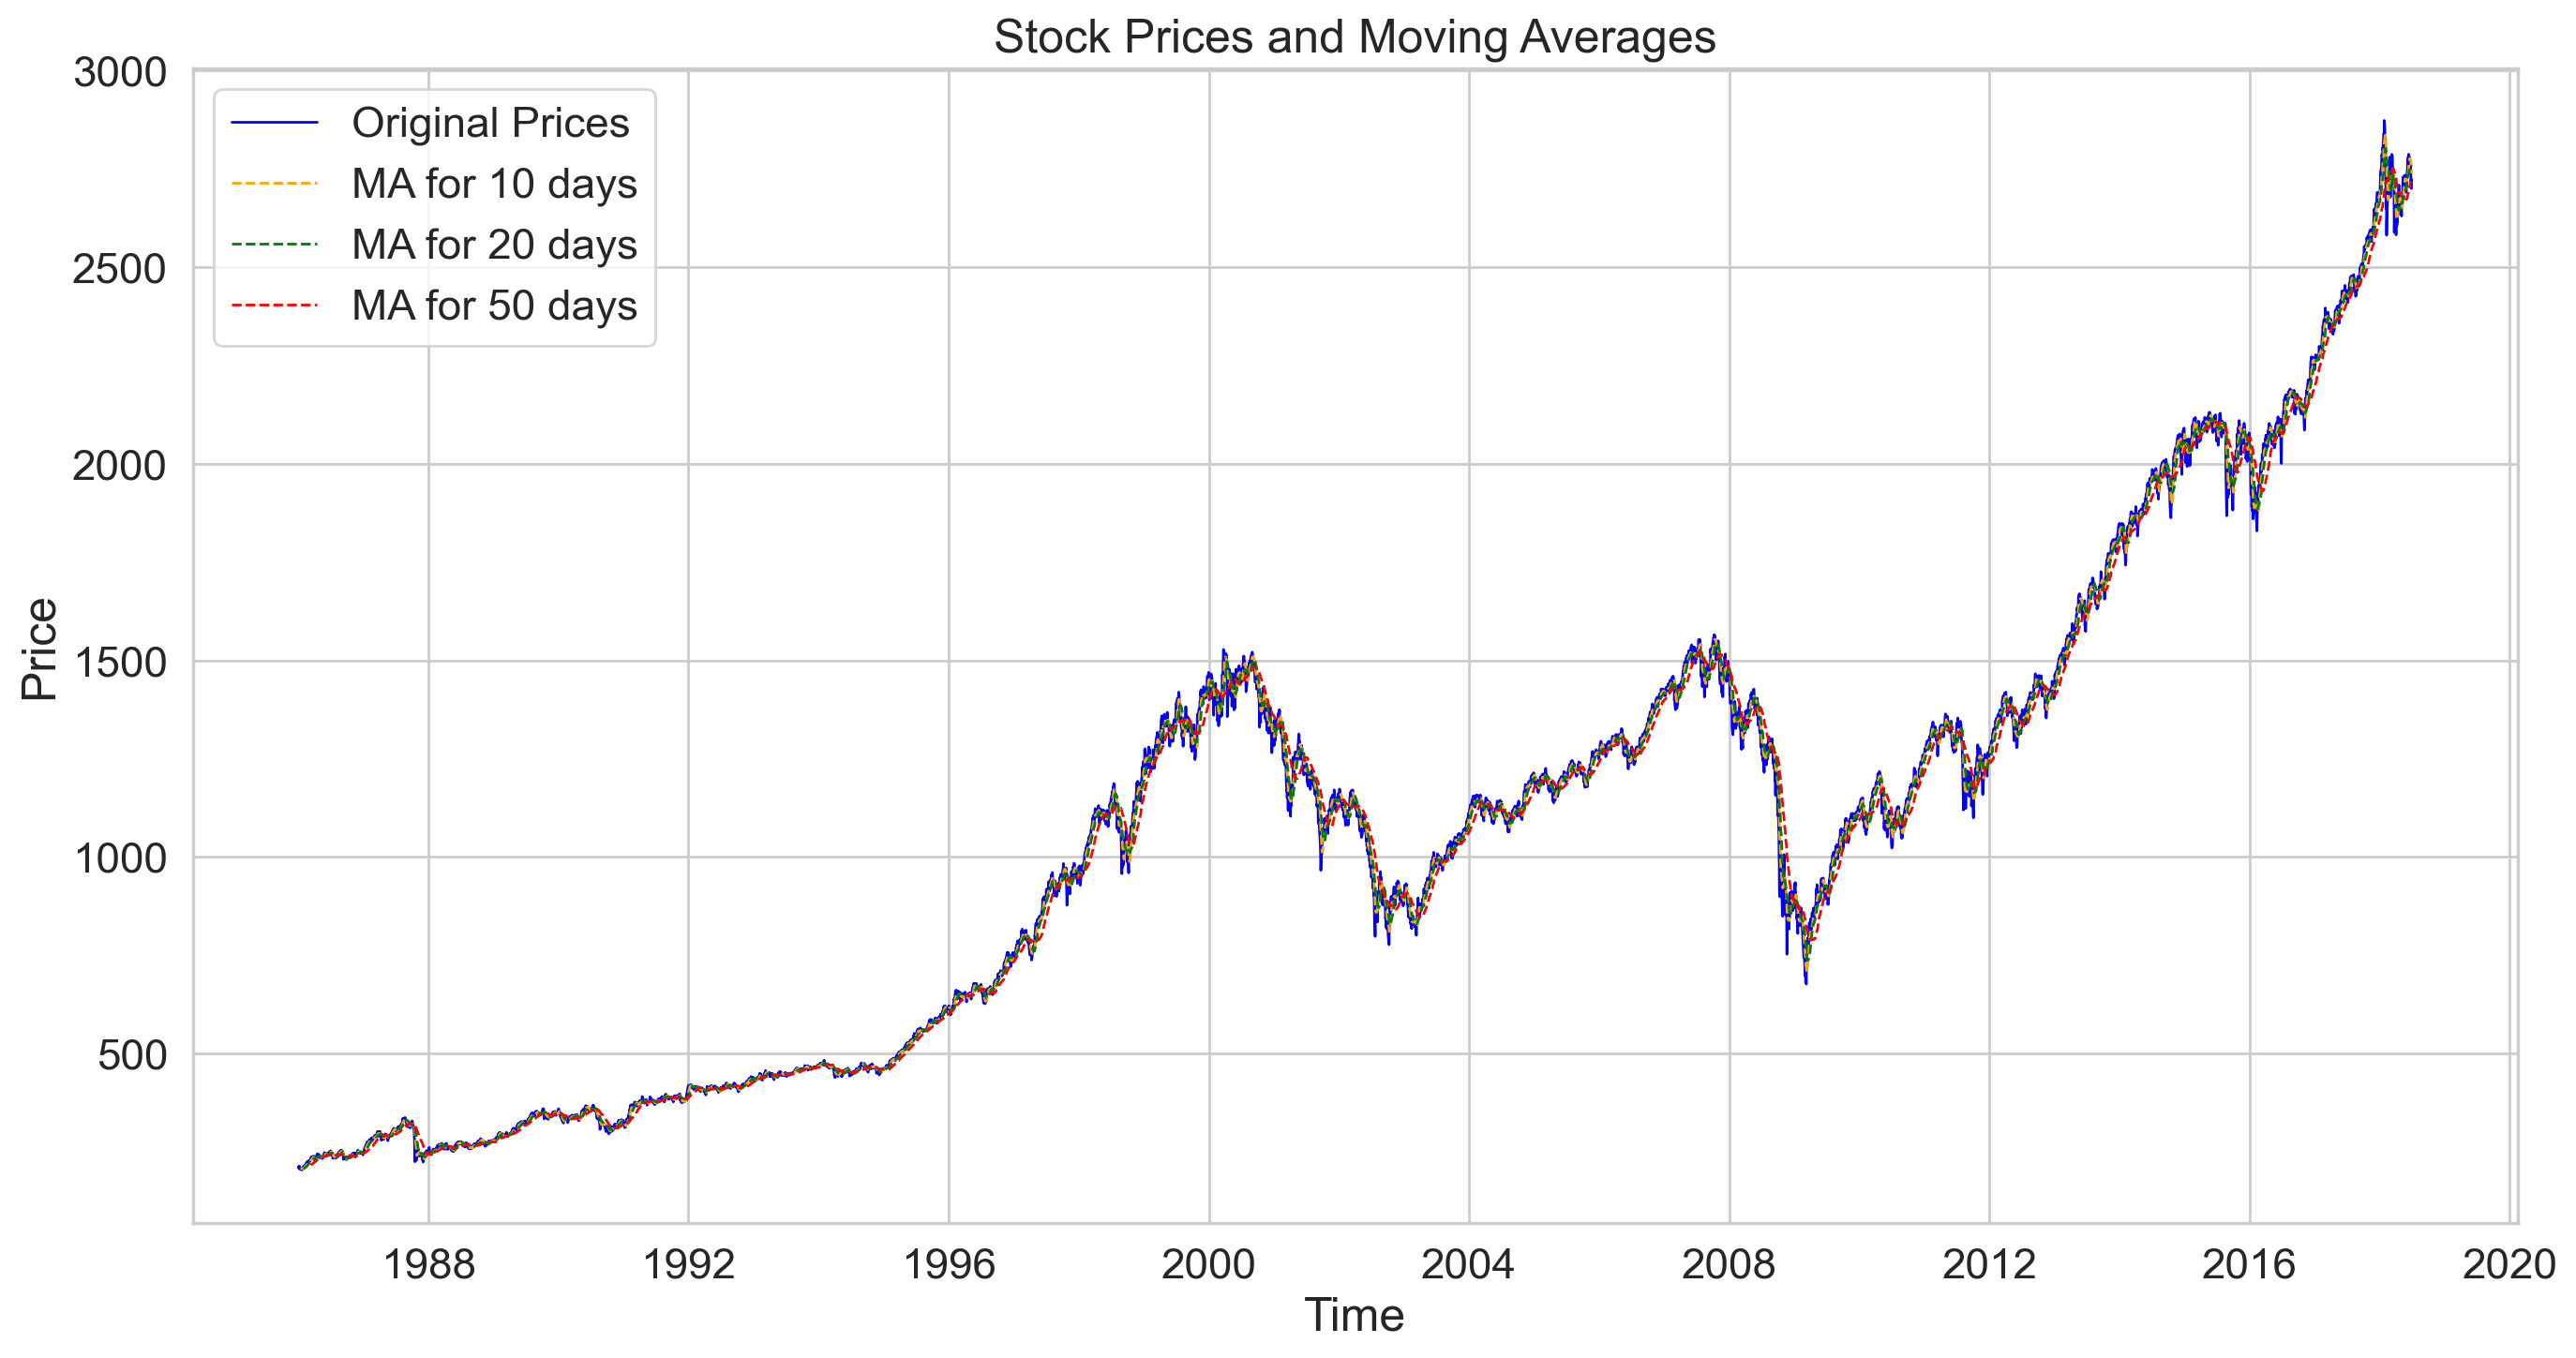

In [24]:
# Moving averages for different windows
ma_10 = df.close.rolling(window=10).mean()
ma_20 = df.close.rolling(window=20).mean()
ma_50 = df.close.rolling(window=50).mean()

plt.figure(figsize=(16, 8))
plt.plot(df.close, label='Original Prices', color='blue', linewidth=1)
plt.plot(ma_10, label='MA for 10 days', linestyle='dashed', color='orange', linewidth=1)
plt.plot(ma_20, label='MA for 20 days', linestyle='dashed', color='green', linewidth=1)
plt.plot(ma_50, label='MA for 50 days', linestyle='dashed', color='red', linewidth=1)
plt.title('Stock Prices and Moving Averages')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [25]:
# Calculate average daily return
daily_returns = df.close.pct_change()
average_daily_return = daily_returns.mean()
print(f'Average Daily Return: {average_daily_return:.4%}')

# Calculate risk (standard deviation of daily returns)
risk = daily_returns.std()
print(f'Standard Deviation of Daily Returns (Risk): {risk:.4%}')


Average Daily Return: 0.0378%
Standard Deviation of Daily Returns (Risk): 1.1325%


The average daily return of the stock is approximately 0.0378%, indicating a modest positive daily trend. However, the standard deviation of daily returns, reflecting the risk, is relatively high at 1.1325%, suggesting notable volatility in the stock's day-to-day performance.

12/12 [==============================] - 0s 10ms/step


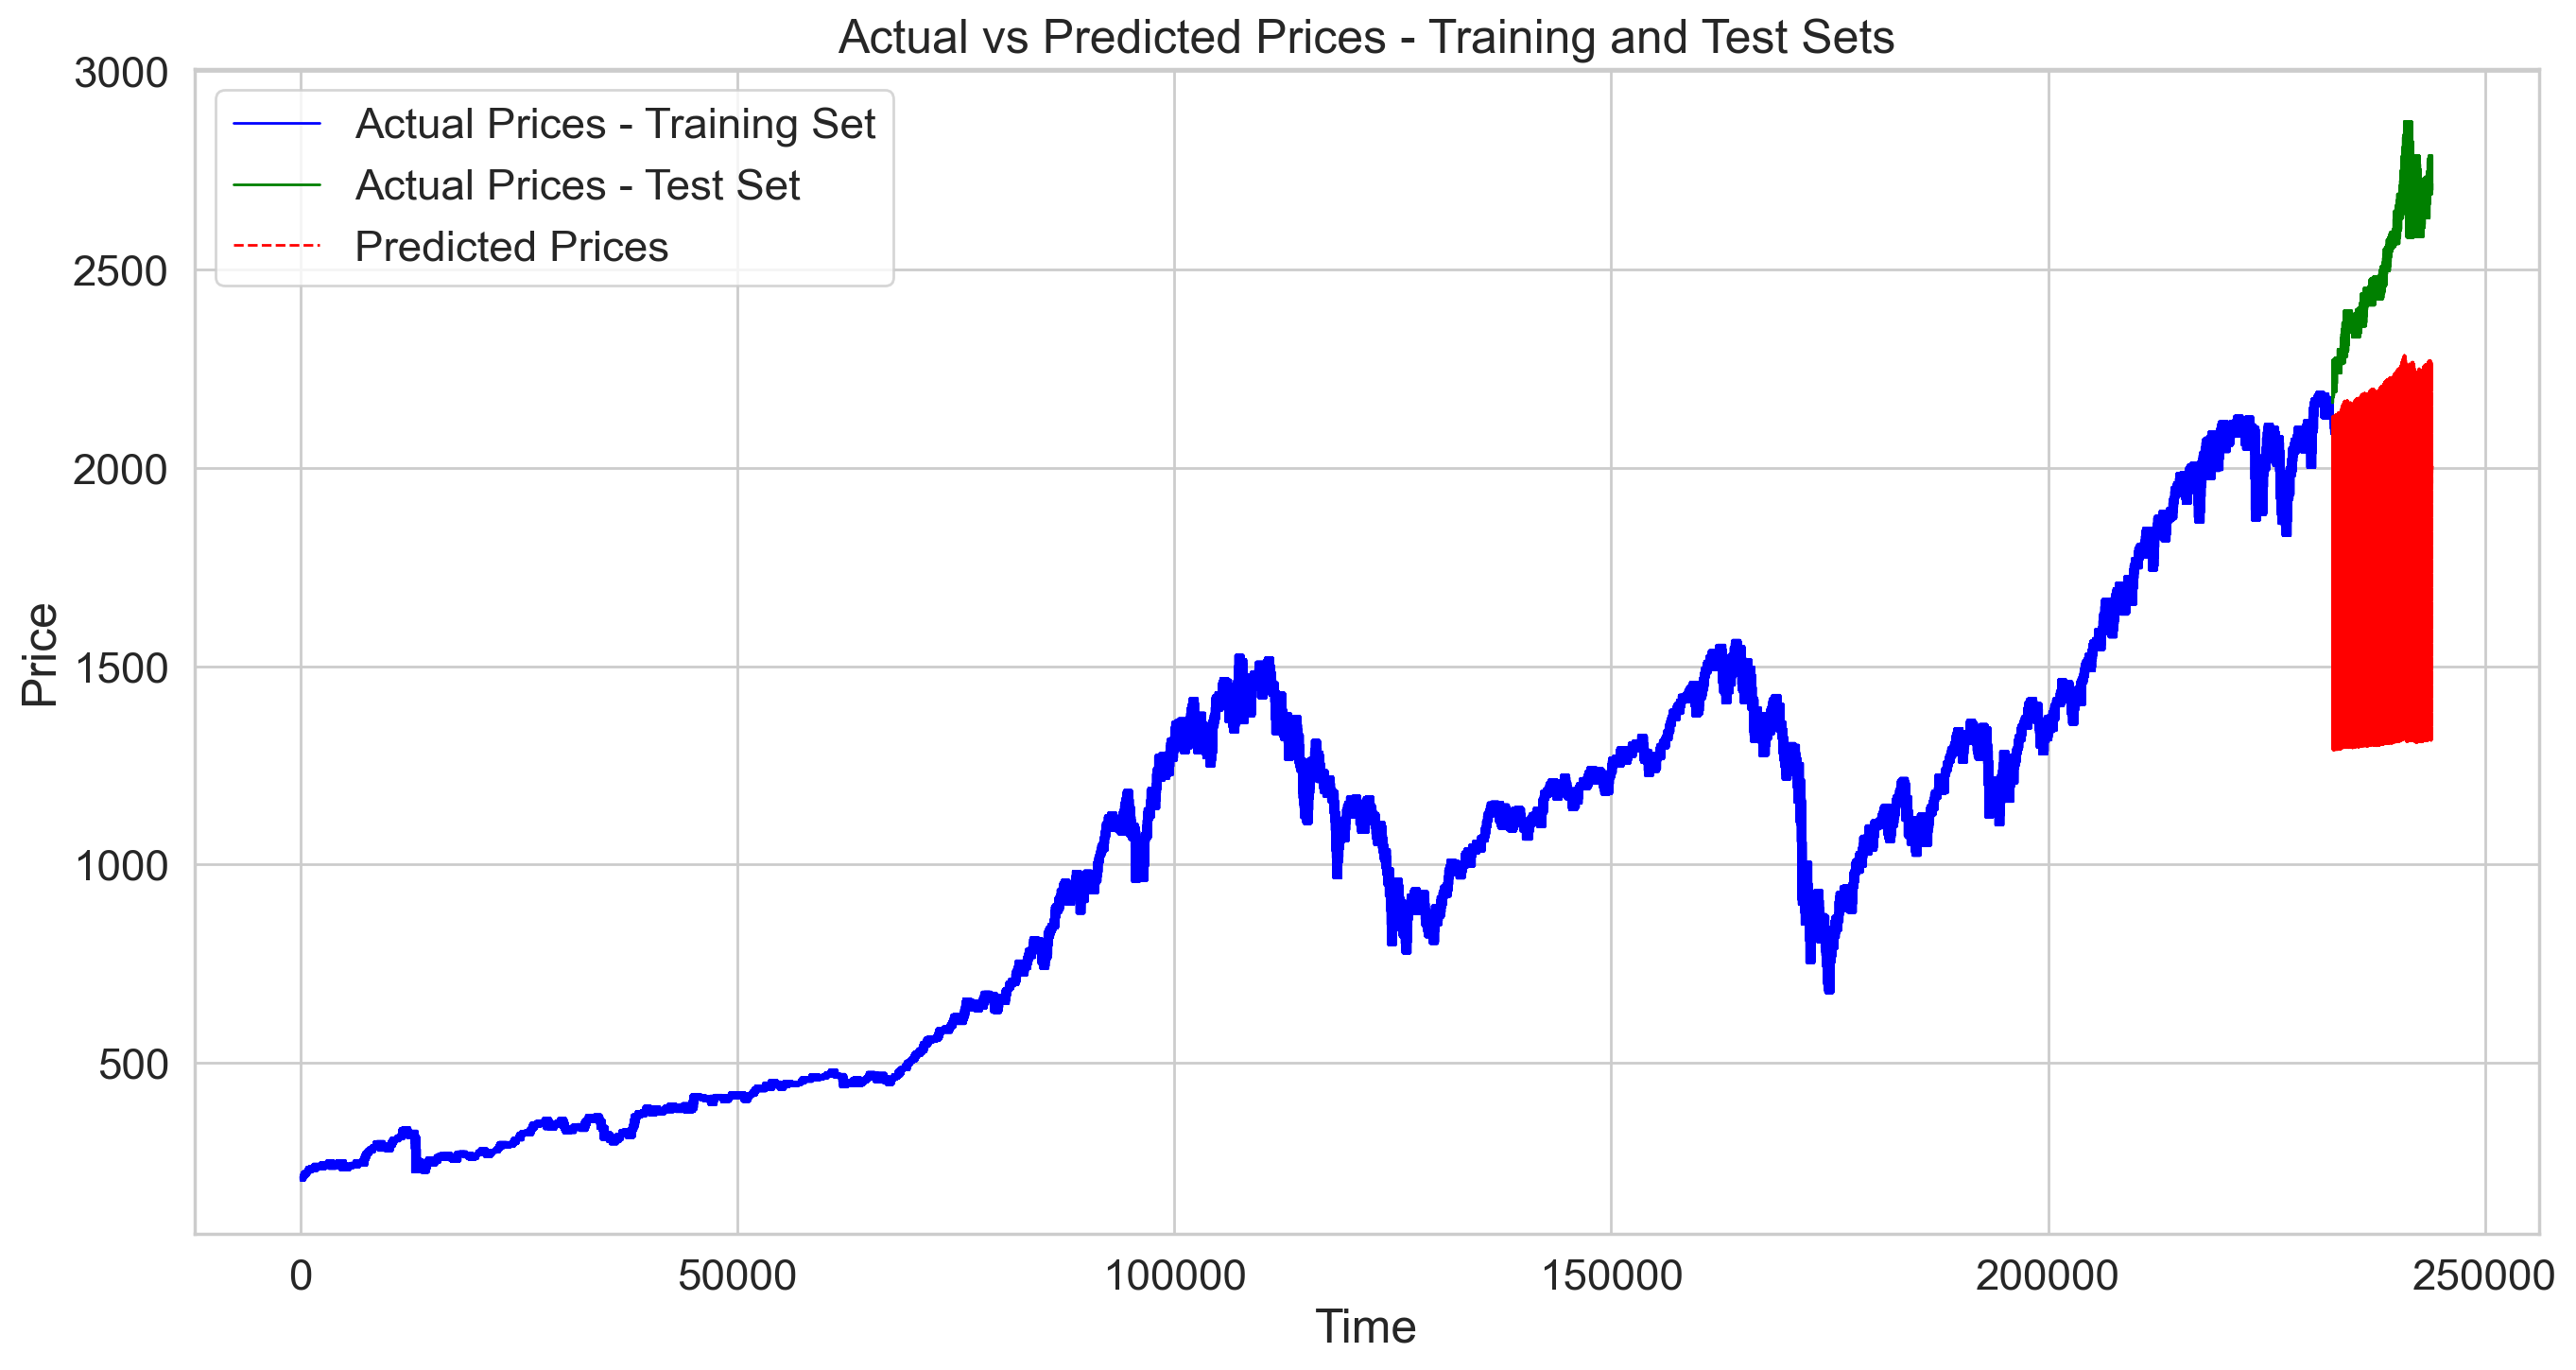

In [26]:
# Assuming the LSTM model has been trained and history is available
X_test_pred_inv = scaler.inverse_transform(model.predict(X_test).reshape(-1, 1))
X_test_inv = scaler.inverse_transform(X_test.reshape(-1, 1))

# Reshape X_train before concatenation
X_train_inv_reshaped = scaler.inverse_transform(X_train.reshape(-1, 1))

# Visualize actual vs predicted prices
plt.figure(figsize=(16, 8))
plt.plot(np.arange(len(X_train_inv_reshaped)), X_train_inv_reshaped, label='Actual Prices - Training Set', color='blue', linewidth=1)
plt.plot(np.arange(len(X_train_inv_reshaped), len(X_train_inv_reshaped) + len(X_test_inv)), X_test_inv, label='Actual Prices - Test Set', color='green', linewidth=1)
plt.plot(np.arange(len(X_train_inv_reshaped), len(X_train_inv_reshaped) + len(X_test_pred_inv)), X_test_pred_inv, label='Predicted Prices', linestyle='dashed', color='red', linewidth=1)
plt.title('Actual vs Predicted Prices - Training and Test Sets')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


### Ensemble

Epoch 1/10
218/218 [==============================] - 9s 23ms/step - loss: 0.1682 - val_loss: 0.2322
Epoch 2/10
218/218 [==============================] - 4s 19ms/step - loss: 0.1042 - val_loss: 0.2035
Epoch 3/10
218/218 [==============================] - 5s 21ms/step - loss: 0.1060 - val_loss: 0.1636
Epoch 4/10
218/218 [==============================] - 5s 21ms/step - loss: 0.1256 - val_loss: 0.1422
Epoch 5/10
218/218 [==============================] - 5s 21ms/step - loss: 0.1338 - val_loss: 0.1412
Epoch 6/10
218/218 [==============================] - 5s 21ms/step - loss: 0.1222 - val_loss: 0.1430
Epoch 7/10
218/218 [==============================] - 4s 20ms/step - loss: 0.1296 - val_loss: 0.1406
Epoch 8/10
218/218 [==============================] - 4s 19ms/step - loss: 0.1229 - val_loss: 0.1277
Epoch 9/10
218/218 [==============================] - 4s 20ms/step - loss: 0.1216 - val_loss: 0.1438
Epoch 10/10
218/218 [==============================] - 4s 19ms/step - loss: 0.1179 - val_lo

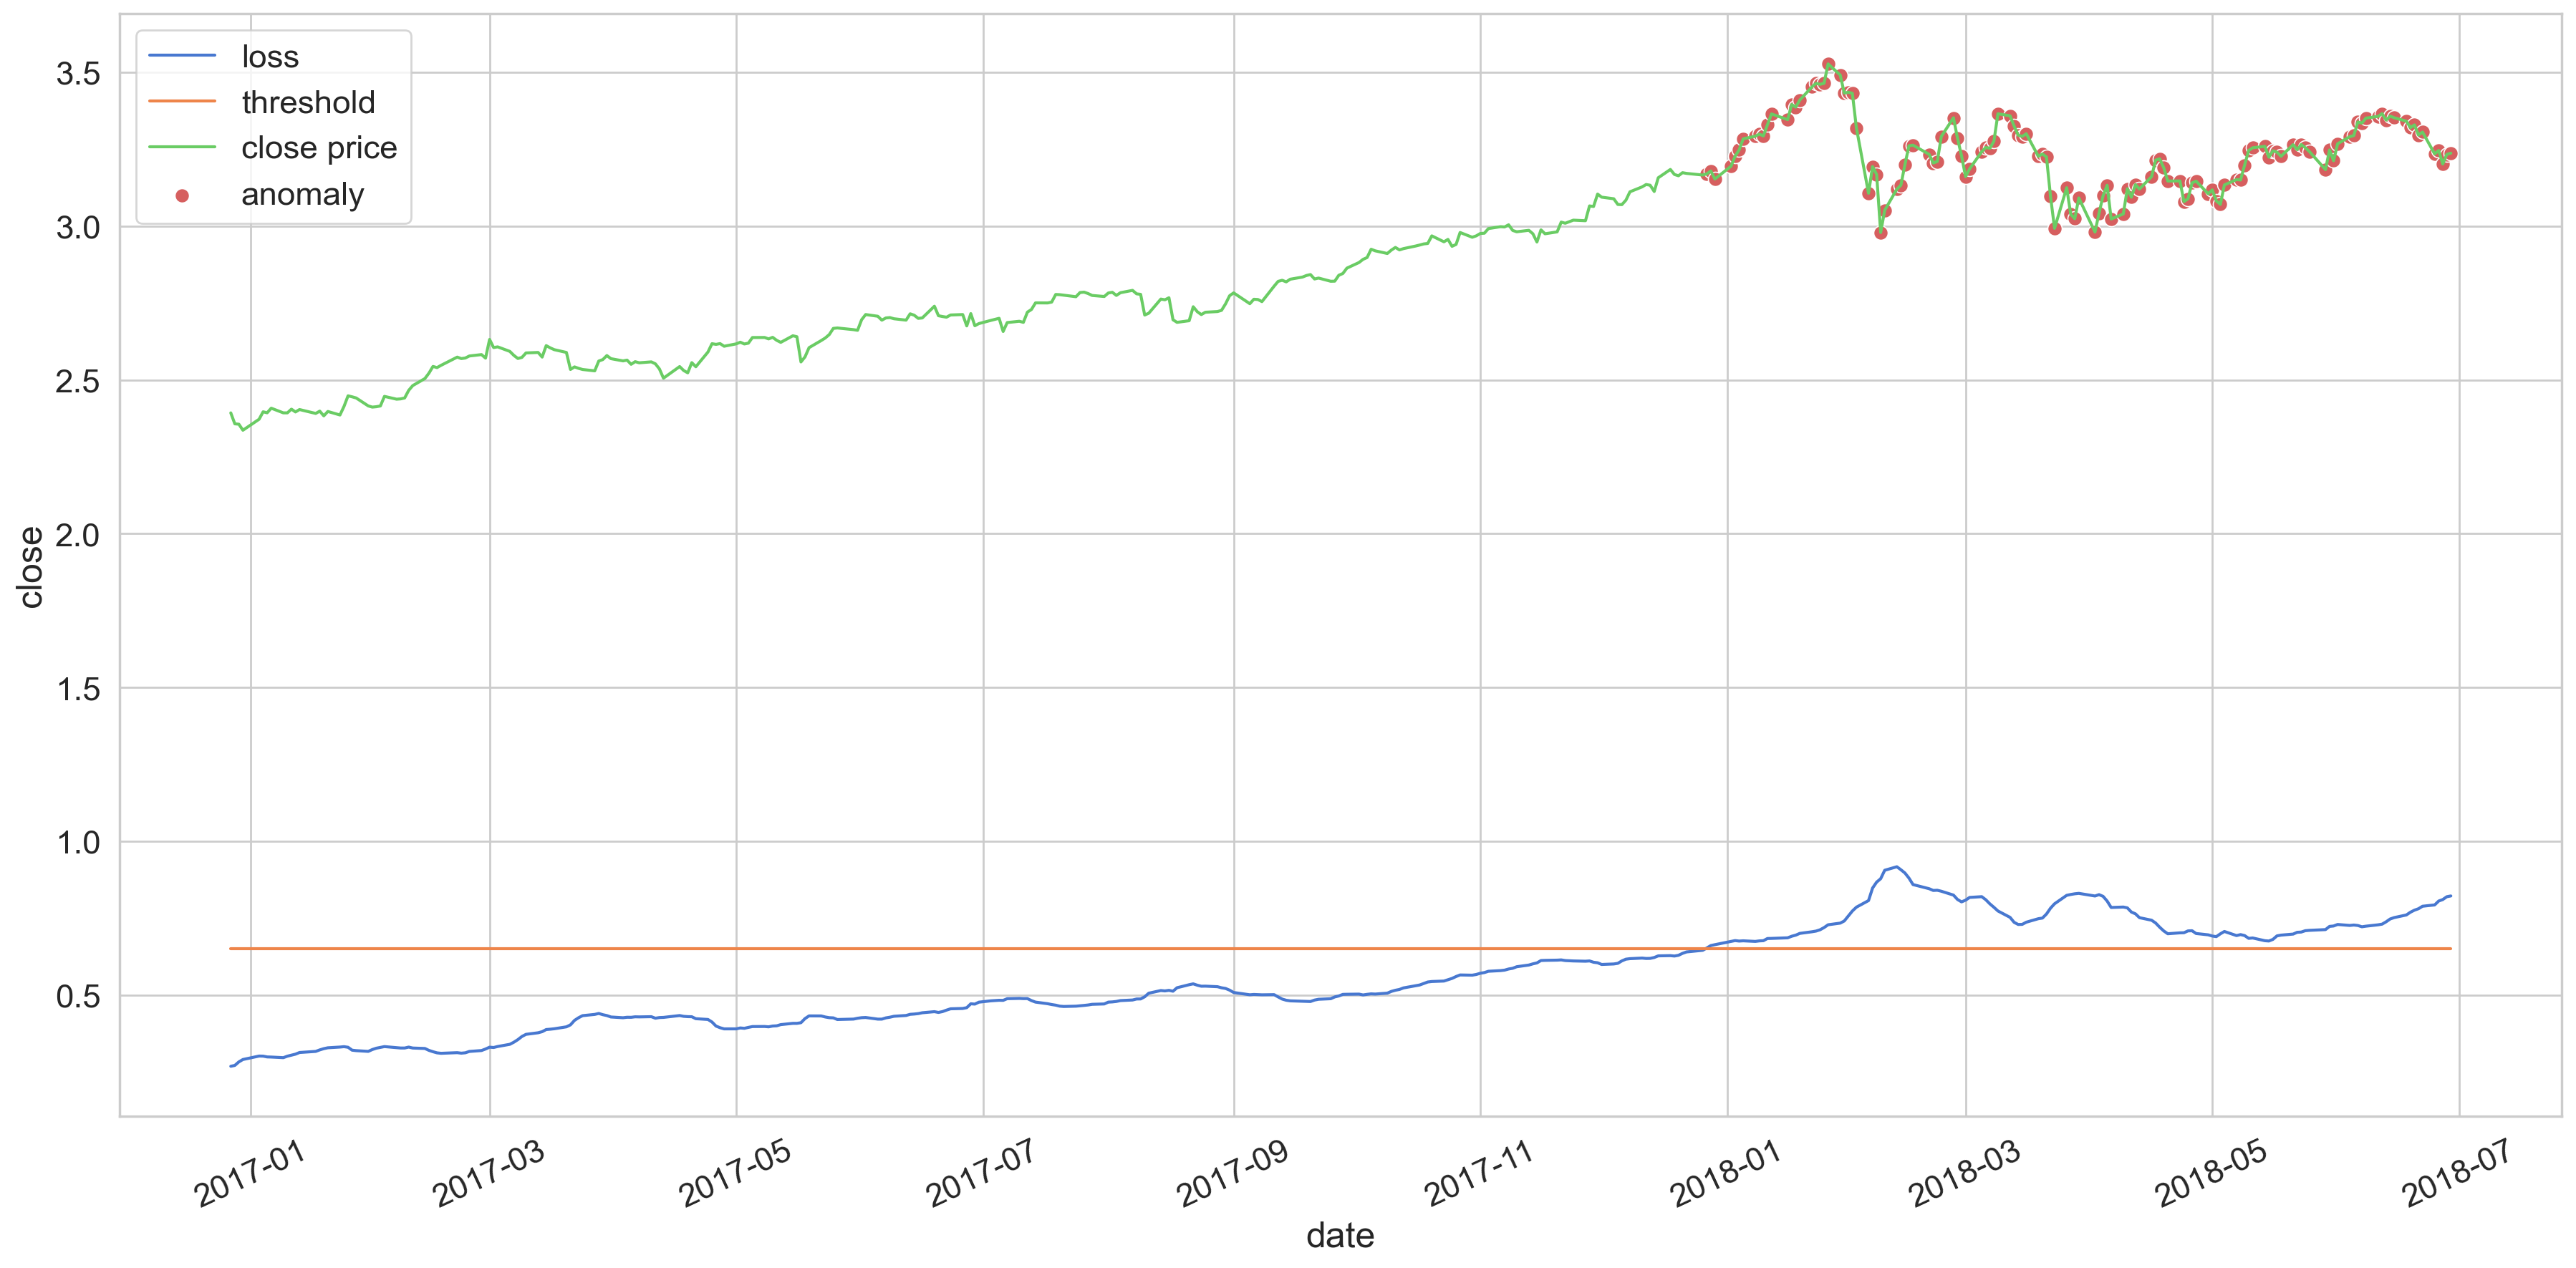

In [27]:
# Number of models in the ensemble
num_models = 3

# Create and train multiple LSTM models
models = []
for _ in range(num_models):
    model = keras.Sequential()
    
    model.add(keras.layers.LSTM(units=64, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(keras.layers.Dropout(rate=0.2))
    model.add(keras.layers.RepeatVector(n=X_train.shape[1]))
    model.add(keras.layers.LSTM(units=64, return_sequences=True))
    model.add(keras.layers.Dropout(rate=0.2))
    model.add(keras.layers.TimeDistributed(keras.layers.Dense(units=X_train.shape[2])))
    model.compile(loss='mae', optimizer='adam')
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        shuffle=False
    )
    models.append(model)

# Ensemble Predictions
ensemble_predictions = np.zeros_like(X_test_pred)

for model in models:
    ensemble_predictions += model.predict(X_test)

ensemble_predictions /= num_models

# Calculate metrics for the ensemble predictions
ensemble_mae_loss = np.mean(np.abs(ensemble_predictions - X_test), axis=1)

# Visualization of ensemble predictions
THRESHOLD = 0.65

ensemble_score_df = pd.DataFrame(index=test[TIME_STEPS:].index)
ensemble_score_df['loss'] = ensemble_mae_loss
ensemble_score_df['threshold'] = THRESHOLD
ensemble_score_df['anomaly'] = ensemble_score_df.loss > ensemble_score_df.threshold
ensemble_score_df['close'] = test[TIME_STEPS:].close

plt.plot(ensemble_score_df.index, ensemble_score_df.loss, label='loss')
plt.plot(ensemble_score_df.index, ensemble_score_df.threshold, label='threshold')
plt.xticks(rotation=25)
plt.legend()

# Visualize anomalies for ensemble predictions
ensemble_anomalies = ensemble_score_df[ensemble_score_df.anomaly == True]

plt.plot(test[TIME_STEPS:].index, test[TIME_STEPS:].close, label='close price')

sns.scatterplot(
  x=ensemble_anomalies.index,
  y=ensemble_anomalies.close,
  color=sns.color_palette()[3],
  s=52,
  label='anomaly'
)
plt.xticks(rotation=25)
plt.legend()


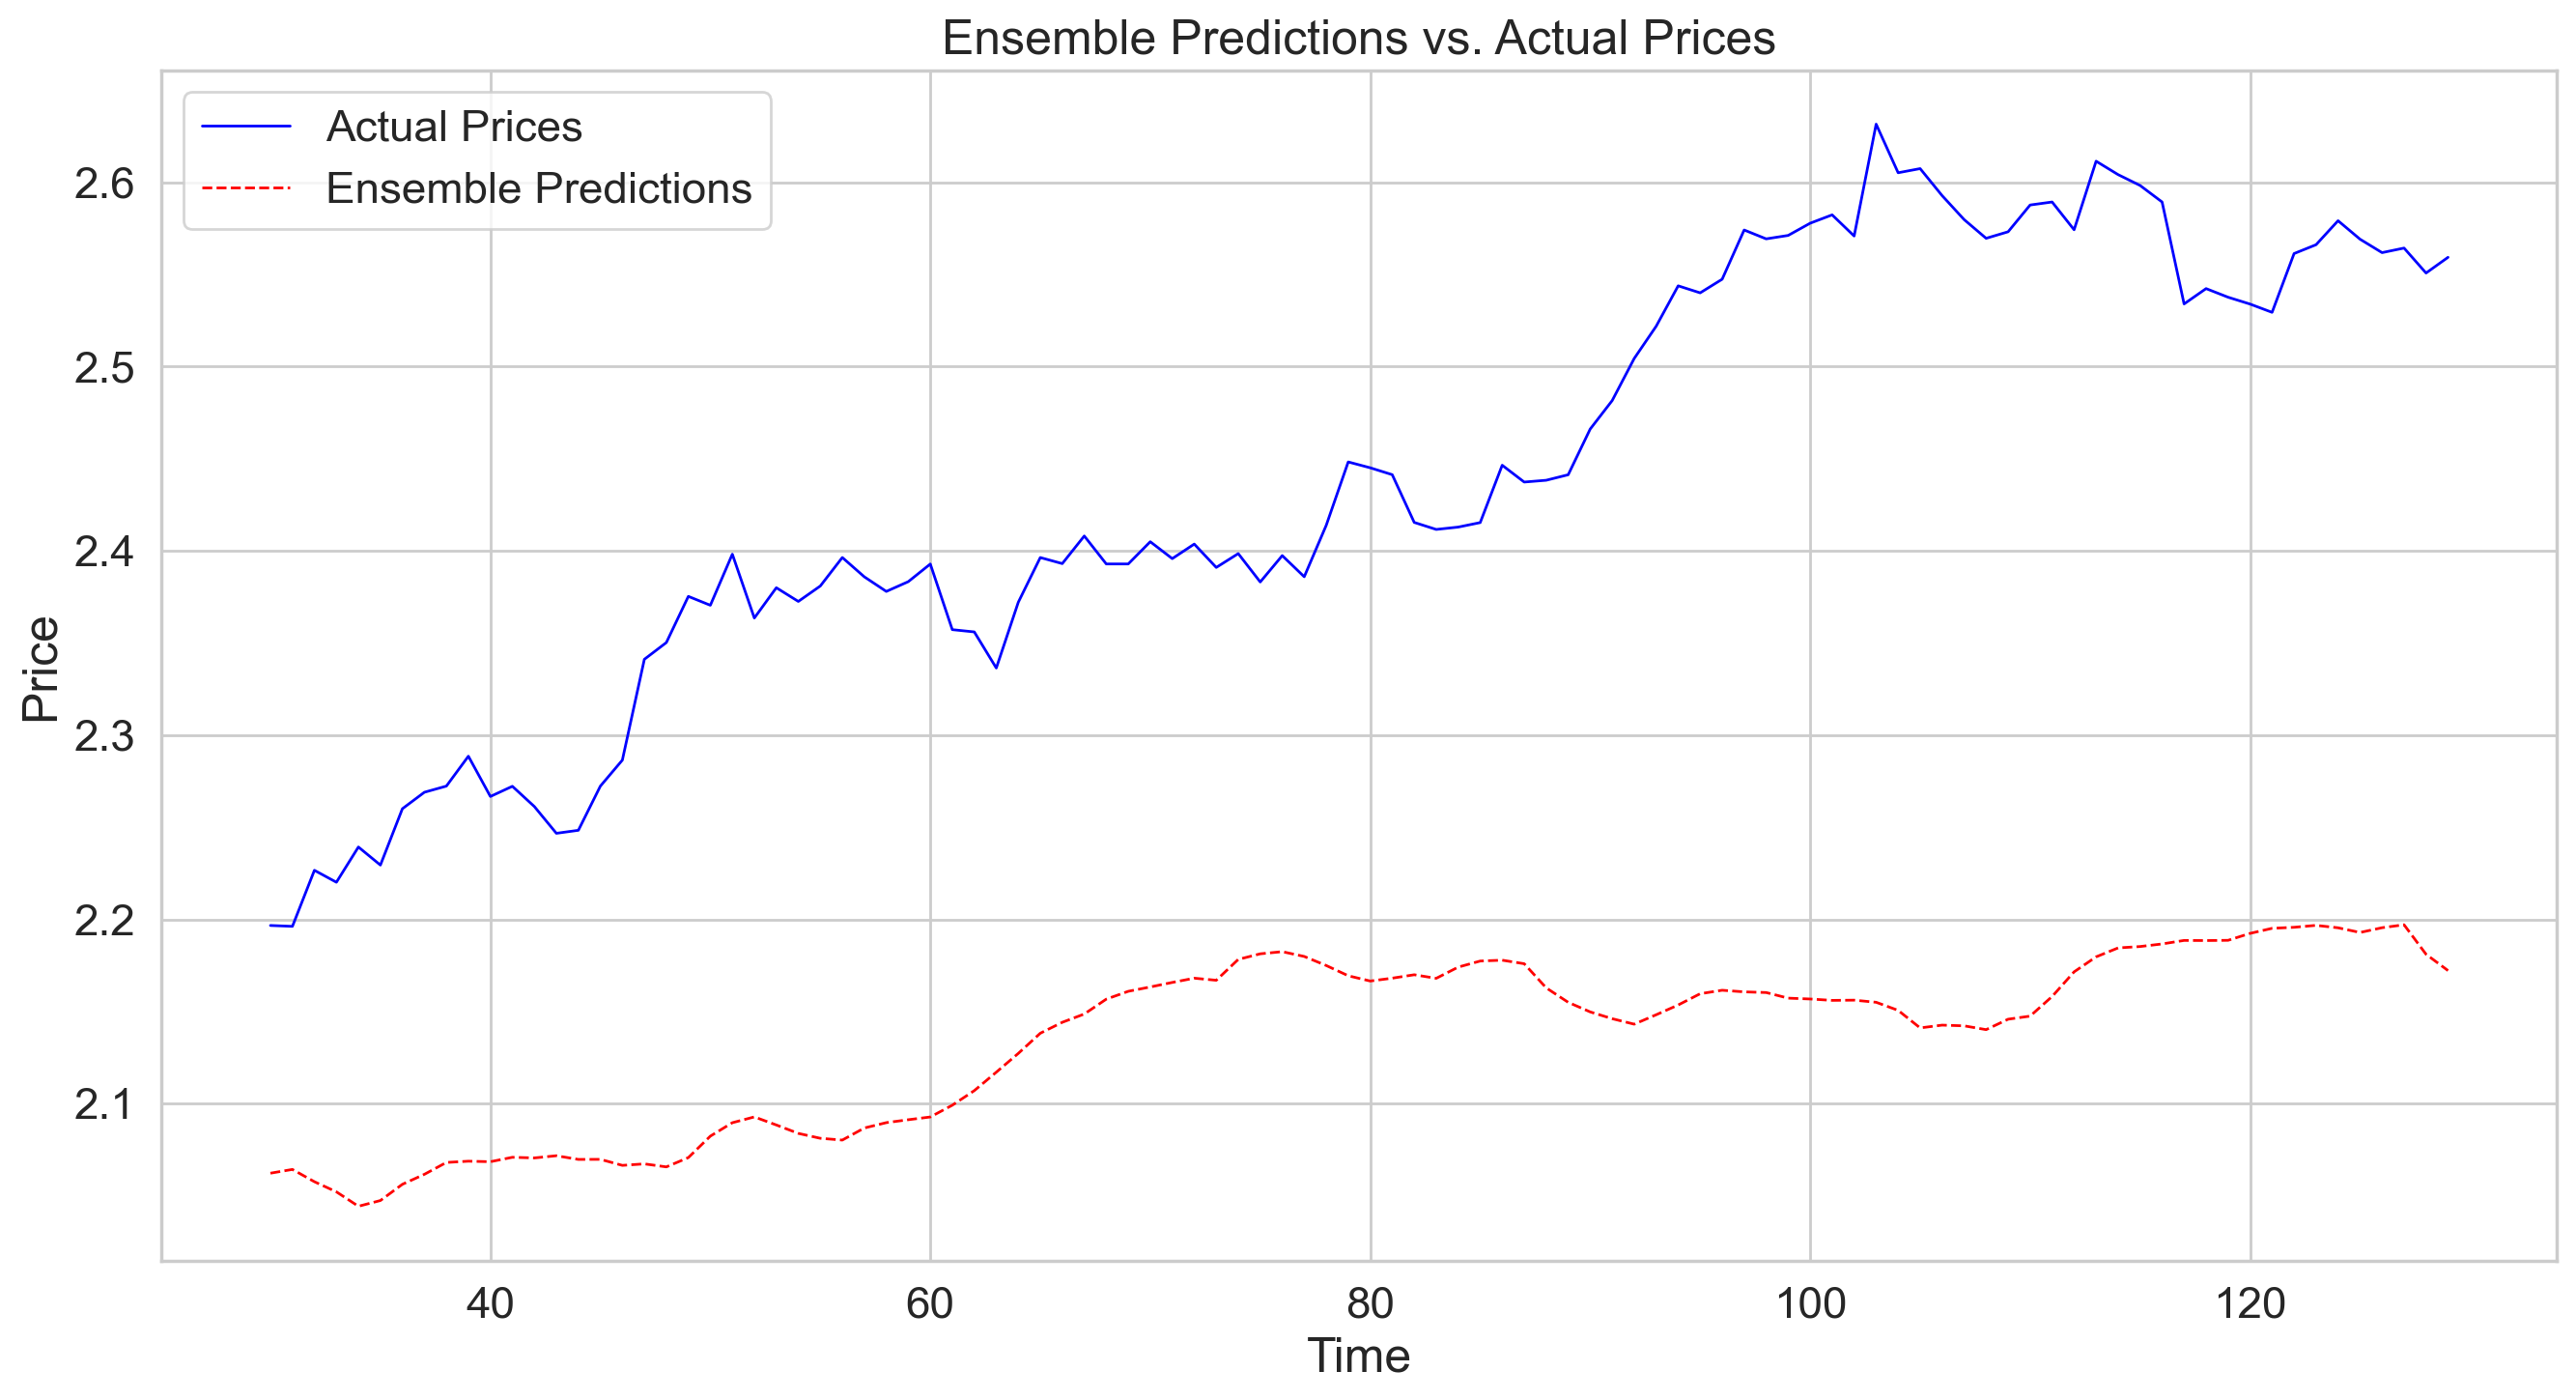

In [28]:
# Visualize ensemble predictions vs. actual values for a specific time window
window_start = 0
window_end = 100  # Adjust the end index as needed

plt.figure(figsize=(16, 8))

# Plot actual prices
plt.plot(np.arange(TIME_STEPS + window_start, TIME_STEPS + window_end), X_test[window_start:window_end, 0], label='Actual Prices', color='blue', linewidth=1)

# Plot ensemble predictions
plt.plot(np.arange(TIME_STEPS + window_start, TIME_STEPS + window_end), ensemble_predictions[window_start:window_end, 0], label='Ensemble Predictions', linestyle='dashed', color='red', linewidth=1)

plt.title('Ensemble Predictions vs. Actual Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Inverse transform the ensemble predictions to the original scale
ensemble_predictions_inv = scaler.inverse_transform(ensemble_predictions.reshape(-1, 1))

# Inverse transform the original scaled test data to the original scale
X_test_inv = scaler.inverse_transform(X_test.reshape(-1, 1))

# Calculate MAE
mae = mean_absolute_error(X_test_inv, ensemble_predictions_inv)
print(f'Mean Absolute Error (MAE): {mae}')

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(X_test_inv, ensemble_predictions_inv))
print(f'Root Mean Squared Error (RMSE): {rmse}')

# Calculate MAPE
mape = np.mean(np.abs((X_test_inv - ensemble_predictions_inv) / X_test_inv)) * 100
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')


Mean Absolute Error (MAE): 296.31635655110676
Root Mean Squared Error (RMSE): 315.15977976044155
Mean Absolute Percentage Error (MAPE): 11.60%
